# Section 7 — Extended Dataset Experiments

**Thesis correspondence:** Section 7

Runs spectral and Laplacian t-SNE on five datasets — MNIST, Kaggle image thumbnails,
credit card transactions, PBMC3k scRNA-seq, Olivetti Faces, and COIL-20 — and
compares KL-divergence cost across PCA, spectral, and Laplacian initialisations.

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import StratifiedShuffleSplit
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import scanpy as sc

from tsne_spectral import (
    tsne_eigen,
    get_original_pairwise_affinities,
    get_symmetric_p_ij,
    initialization,
    get_low_dimensional_affinities,
    get_gradient,
    spectral_init,
    laplacian_eigenmaps_init,
    load_mnist,
    load_coil20,
    load_olivetti,
    plot_embedding,
)

# importing t-SNE with the eigenmap initialization

# All core t-SNE functions (grid_search, get_original_pairwise_affinities,
# get_symmetric_p_ij, spectral_init, laplacian_eigenmaps_init, initialization,
# get_low_dimensional_affinities, get_gradient, tsne_eigen) are imported
# from tsne_spectral above.

# importing multiple datasets

## MNIST

In [ ]:
x_train_pca, y_train = load_mnist(n_samples=500, pca_components=40)

## IMAGES

In [4]:
train_path = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\train"
labels_path = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\trainLabels.csv"

# Load labels
labels_df = pd.read_csv(labels_path)
print(labels_df.head())

# Example: load one image + match label
filename = "1.png"
img = Image.open(os.path.join(train_path, filename))
img_array = np.array(img)

# Look up label from CSV
image_id = int(filename.split(".")[0])  # get "1" from "1.png"
label = labels_df.loc[labels_df['id'] == image_id, 'label'].values[0]

print("Image shape:", img_array.shape, "Label:", label)

   id       label
0   1        frog
1   2       truck
2   3       truck
3   4        deer
4   5  automobile
Image shape: (32, 32, 3) Label: frog


In [5]:
# 0) Build a numerically sorted file list + labels aligned to files
files = sorted(
    [f for f in os.listdir(train_path) if f.endswith('.png')],
    key=lambda x: int(os.path.splitext(x)[0])
)
paths_all = [os.path.join(train_path, f) for f in files]

labels_df = labels_df.copy()
labels_df['id'] = labels_df['id'].astype(int)
labels_df = labels_df.set_index('id')

y_all = np.array([labels_df.at[int(os.path.splitext(f)[0]), 'label'] for f in files])

# 1) Make a stratified subset of 500 images (≈50 per class)
le_all = LabelEncoder()
y_all_enc = le_all.fit_transform(y_all.astype(str))

rng = np.random.default_rng(0)
idx_500 = []
for c in range(len(le_all.classes_)):
    idx_c = np.where(y_all_enc == c)[0]
    take = min(50, len(idx_c))
    idx_500.append(rng.choice(idx_c, size=take, replace=False))
idx_500 = np.concatenate(idx_500)

paths_500 = [paths_all[i] for i in idx_500]
y_500 = y_all[idx_500]

# 2) Extract semantic features with a pretrained CNN (ResNet18)
tfm = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class PathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths, self.transform = paths, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        return self.transform(img) if self.transform else img

loader = DataLoader(PathsDataset(paths_500, tfm), batch_size=64, shuffle=False, num_workers=0)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval()
backbone = torch.nn.Sequential(*list(model.children())[:-1])

feats = []
with torch.no_grad():
    for xb in loader:
        z = backbone(xb).squeeze(-1).squeeze(-1)
        feats.append(z.cpu().numpy())
X_feat = np.concatenate(feats, axis=0)

# 3) PCA → (optionally) row-normalize → your t-SNE
X_40 = PCA(n_components=40, random_state=0).fit_transform(X_feat)
X_40 = normalize(X_40)


## Credit card

In [6]:
# 1) Point this to your downloaded CSV (Kaggle: "creditcard.csv")
DATA_PATH = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"
df = pd.read_csv(DATA_PATH)

# 2) Features/labels
y = df['Class'].values
X = df.drop(columns=['Class']).values

# (optional) Downsample to something small but stratified for plotting
sss = StratifiedShuffleSplit(n_splits=1, test_size=500, random_state=0)
idx_train, idx_sample = next(sss.split(X, y))
X_s, y_s = X[idx_sample], y[idx_sample]

# 3) Scale → PCA 
X_s = StandardScaler().fit_transform(X_s)
X_pca_cc = PCA(n_components=20, random_state=0).fit_transform(X_s)

## RNA

In [7]:
# 1) Load PBMC3k (single-cell RNA-seq)
adata = sc.datasets.pbmc3k()

# 2) Standard scRNA-seq preprocessing
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=500, subset=True)
sc.pp.scale(adata, max_value=10)

# 3) PCA → neighbors → Leiden clusters (labels)
sc.tl.pca(adata, n_comps=40, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.leiden(adata, resolution=0.6)

X_pca_rna = adata.obsm['X_pca']
labels = adata.obs['leiden'].to_numpy()

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\stat303\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\wpbro\AppData\Local\Temp\ipykernel_26920\4281002229.py:15: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6)


## Olivetti Faces

In [ ]:
X_pca_face, y_f = load_olivetti(pca_components=40)

## COIL-20

In [ ]:
coil_path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X_pca_coil, y_c = load_coil20(data_dir=coil_path, pca_components=40)

### variable names:

- x_train_pca (MNIST)
- X_40 (resnet18 images)
- X_pca_cc (credit card)
- X_pca_rna (RNA)
- X_pca_face (faces)
- X_pca_coil (coil-20)


what i need: 
- stats for everything except MNIST
- plot KL vs iteration (so like 250 iterations and it gets here, then 500 and here, 750 and here, ...)
    - plot time with this to a specific cost value (make the cost threshold: ???)
- Maybe a table comparing all of the data gathered (for some data that we dont explicitly show but still want to reference)

# Running t-SNE

## IMAGES

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.706329163509449
Completed Low Dimensional Embedding: Final Value of Cost Function is 2.706329163509449


C:\Users\wpbro\AppData\Local\Temp\ipykernel_22548\1193563830.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(le.classes_))


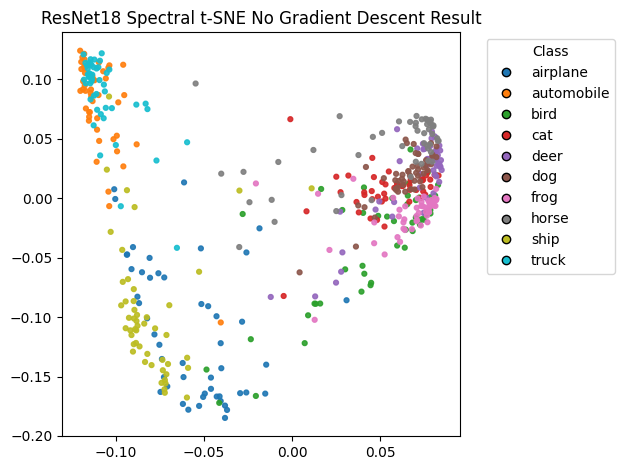

In [33]:
Y = tsne_eigen(X_40, initialization_method="spectral", T=3)

le = LabelEncoder()
y_enc = le.fit_transform(y_500.astype(str))

cmap = plt.cm.get_cmap('tab10', len(le.classes_))
plt.scatter(Y[:, 0], Y[:, 1], c=y_enc, cmap=cmap, s=12, alpha=0.9)
handles = [plt.Line2D([0],[0], marker='o', linestyle='', markerfacecolor=cmap(i), markeredgecolor='k', label=cls) for i, cls in enumerate(le.classes_)]
plt.legend(handles=handles, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('ResNet18 Spectral t-SNE No Gradient Descent Result')
plt.tight_layout()
plt.show()

## Credit Card

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.5591091030305955
Completed Low Dimensional Embedding: Final Value of Cost Function is 2.5591091030305955


C:\Users\wpbro\AppData\Local\Temp\ipykernel_22548\1064418209.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1")


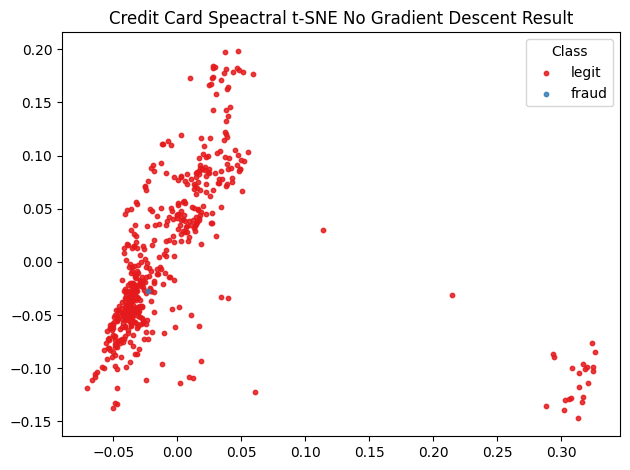

In [34]:
Y = tsne_eigen(X_pca_cc, initialization_method="spectral", T=3)

cmap = plt.cm.get_cmap("Set1")

plt.scatter(Y[y_s==0,0], Y[y_s==0,1], c=[cmap(0)], s=10, alpha=0.85, label="legit")
plt.scatter(Y[y_s==1,0], Y[y_s==1,1], c=[cmap(1)], s=10, alpha=0.85, label="fraud")

plt.title("Credit Card Speactral t-SNE No Gradient Descent Result")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


## RNA

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.9644672170688695
Iteration 50: Value of Cost Function is 3.6342259842967404
Iteration 100: Value of Cost Function is 3.3575478987382414
Iteration 150: Value of Cost Function is 3.1927304464995543
Iteration 200: Value of Cost Function is 3.110520776293318
Iteration 250: Value of Cost Function is 3.059413198433249
Iteration 300: Value of Cost Function is 3.0231405316025795
Iteration 350: Value of Cost Function is 2.995335008240526
Iteration 400: Value of Cost Function is 2.9729736290705917
Iteration 450: Value of Cost Function is 2.9543342902954937
Iteration 500: Value of Cost Function is 2.9384502306762297
Iteration 550: 

C:\Users\wpbro\AppData\Local\Temp\ipykernel_22548\3578972870.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(le.classes_))


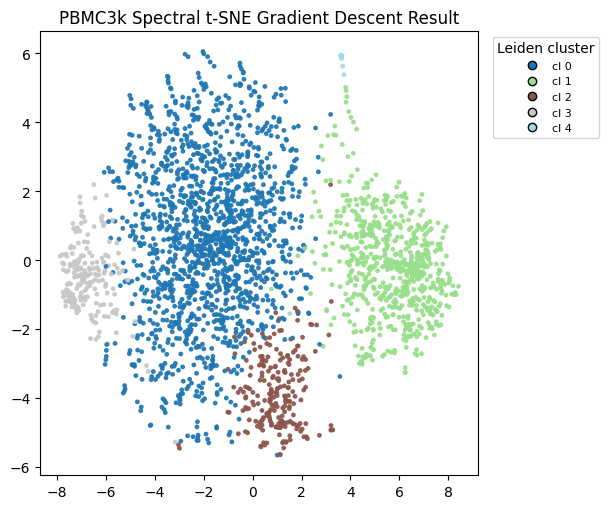

In [35]:
Y = tsne_eigen(X_pca_rna, initialization_method="spectral", T=1000)

# 5) Plot colored by Leiden cluster
le = LabelEncoder()
y_enc = le.fit_transform(labels.astype(str))
cmap = plt.cm.get_cmap('tab20', len(le.classes_))

plt.figure(figsize=(6.2,5.2))
plt.scatter(Y[:,0], Y[:,1], c=y_enc, cmap=cmap, s=6, alpha=0.9)
handles = [plt.Line2D([0],[0], marker='o', linestyle='',
                      markerfacecolor=cmap(i), markeredgecolor='k', label=f'cl {cls}')
           for i, cls in enumerate(le.classes_)]
plt.legend(handles=handles, title='Leiden cluster', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.title('PBMC3k Spectral t-SNE Gradient Descent Result')
plt.tight_layout(); plt.show()

# Cost function comparison

In [12]:
# ===============================
# Helpers to compute t-SNE KL
# ===============================
def _Hbeta(D_row, beta):
    P = np.exp(-D_row * beta)
    P[0] = 0.0
    sumP = P.sum()
    if sumP <= 1e-12:
        return 0.0, P
    P /= sumP
    H = -np.sum(P * np.log2(P + 1e-12))
    return H, P

def _binary_search_perplexity(D_row, target_perp=30.0, tol=1e-5, max_iter=50):
    logU = np.log2(target_perp)
    beta = 1.0
    betamin, betamax = -np.inf, np.inf
    H, P = _Hbeta(D_row, beta)
    it = 0
    while abs(H - logU) > tol and it < max_iter:
        if H > logU:
            betamin = beta
            beta = beta * 2 if not np.isfinite(betamax) else (beta + betamax) / 2
        else:
            betamax = beta
            beta = beta / 2 if not np.isfinite(betamin) else (beta + betamin) / 2
        H, P = _Hbeta(D_row, beta)
        it += 1
    return P

def tsne_joint_probabilities(X, perplexity=30.0):
    # squared distances
    sum_X = np.sum(np.square(X), axis=1)
    D = sum_X[:, None] + sum_X[None, :] - 2 * X @ X.T
    np.maximum(D, 0, out=D)
    N = X.shape[0]
    P = np.zeros((N, N), dtype=np.float64)
    for i in range(N):
        Pi = _binary_search_perplexity(D[i].copy(), target_perp=perplexity)
        P[i] = Pi
    P = (P + P.T)
    P /= max(P.sum(), 1e-12)
    np.fill_diagonal(P, 0.0)
    return P

def tsne_q_from_Y(Y):
    sum_Y = np.sum(np.square(Y), axis=1)
    dist = sum_Y[:, None] + sum_Y[None, :] - 2 * Y @ Y.T
    num = 1.0 / (1.0 + np.maximum(dist, 0))
    np.fill_diagonal(num, 0.0)
    Q = num / max(num.sum(), 1e-12)
    return Q

def tsne_kl(P, Q):
    eps = 1e-12
    return float(np.sum(P * (np.log(P + eps) - np.log(Q + eps))))

# ===============================
# Experiment runner
# ===============================
def run_many_tsne_comparisons(X, y, n_runs=12, sample_size=500, pca_components=20,
                              perplexity=30.0, T=1000):
    scaler = StandardScaler()
    pca = PCA(n_components=pca_components, random_state=0)

    rows = []
    for seed in range(n_runs):
        # stratified sample of 'sample_size' rows
        sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=seed)
        idx_sample, _ = next(sss.split(X, y))
        Xs = X[idx_sample]
        ys = y[idx_sample]

        # scale → PCA (these are the high-D features for affinities)
        Xp = pca.fit_transform(scaler.fit_transform(Xs))

        # build P once per sample (same P for both inits)
        P = tsne_joint_probabilities(Xp, perplexity=perplexity)

        # --- your t-SNE, two inits ---
        Y_spec = tsne_eigen(Xp, initialization_method="spectral", T=T)
        Y_pca  = tsne_eigen(Xp, initialization_method="PCA", T=T)
        Y_lap  = tsne_eigen(Xp, initialization_method="laplacian", T=T)

        # If your function can return final KL internally, replace the two lines below with that value.
        Q_spec = tsne_q_from_Y(Y_spec);  kl_spec = tsne_kl(P, Q_spec)
        Q_pca  = tsne_q_from_Y(Y_pca);   kl_pca  = tsne_kl(P, Q_pca)
        Q_lap  = tsne_q_from_Y(Y_lap);   kl_lap  = tsne_kl(P, Q_lap)

        rows.append({"run": seed, "init": "spectral", "KL": kl_spec})
        rows.append({"run": seed, "init": "PCA",      "KL": kl_pca})
        rows.append({"run": seed, "init": "laplacian",      "KL": kl_lap})
        rows.append({"run": seed, "init": "delta(PCA - spectral)", "KL": kl_pca - kl_spec})
        rows.append({"run": seed, "init": "delta(PCA - laplacian)", "KL": kl_pca - kl_lap})
        rows.append({"run": seed, "init": "delta(laplacian - spectral)", "KL": kl_lap - kl_spec})

    res = pd.DataFrame(rows)
    return res

# ===============================
# Use it on your credit-card CSV
# ===============================
DATA_PATH = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"
df = pd.read_csv(DATA_PATH)
y = df["Class"].values
X = df.drop(columns=["Class"]).values

res = run_many_tsne_comparisons(
    X, y,
    n_runs=12,          # 10–15 as you wanted
    sample_size=500,
    pca_components=20,
    perplexity=30.0,
    T=1000
)

# Table view (paired per run)
print(res.pivot_table(index="run", columns="init", values="KL"))

# Quick paired-lines viz
runs = sorted(res[res["init"].isin(["spectral","PCA", "laplacian"])]["run"].unique())
kl_spec = res[res["init"]=="spectral"].sort_values("run")["KL"].values
kl_pca  = res[res["init"]=="PCA"].sort_values("run")["KL"].values
kl_lap  = res[res["init"]=="laplacian"].sort_values("run")["KL"].values

plt.figure(figsize=(6,4))
for i,_ in enumerate(runs):
    plt.plot([0,1], [kl_spec[i], kl_pca[i], kl_lap{i}], marker='o', alpha=0.8)
plt.xticks([0,1], ["spectral","PCA", "laplacian"])
plt.ylabel("KL cost (lower is better)")
plt.title("t-SNE KL across runs (n=500)")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout(); plt.show()

# Boxplot summary
plt.figure(figsize=(5,4))
plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA", "laplacian"], showmeans=True)
plt.ylabel("KL cost")
plt.title("KL distribution by initialization")
plt.tight_layout(); plt.show()


SyntaxError: invalid syntax. Perhaps you forgot a comma? (57228959.py, line 128)

In [4]:
# =========================
# DEFINITIONS & UTILITIES
# =========================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize
from sklearn.decomposition import PCA

# (Optional / Only needed for image dataset)
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# (Optional / Only needed for PBMC3k dataset)
import scanpy as sc

# -------- t-SNE probability & KL helpers (fallback if tsne_eigen doesn't return KL) --------
def _Hbeta(D_row, beta):
    P = np.exp(-D_row * beta)
    P[0] = 0.0
    sumP = P.sum()
    if sumP <= 1e-12:
        return 0.0, P
    P /= sumP
    H = -np.sum(P * np.log2(P + 1e-12))
    return H, P

def _binary_search_perplexity(D_row, target_perp=30.0, tol=1e-5, max_iter=50):
    logU = np.log2(target_perp)
    beta = 1.0
    betamin, betamax = -np.inf, np.inf
    H, P = _Hbeta(D_row, beta)
    it = 0
    while abs(H - logU) > tol and it < max_iter:
        if H > logU:
            betamin = beta
            beta = beta * 2 if not np.isfinite(betamax) else (beta + betamax) / 2
        else:
            betamax = beta
            beta = beta / 2 if not np.isfinite(betamin) else (beta + betamin) / 2
        H, P = _Hbeta(D_row, beta)
        it += 1
    return P

def tsne_joint_probabilities(X, perplexity=30.0):
    sum_X = np.sum(np.square(X), axis=1)
    D = sum_X[:, None] + sum_X[None, :] - 2 * X @ X.T
    np.maximum(D, 0, out=D)
    N = X.shape[0]
    P = np.zeros((N, N), dtype=np.float64)
    for i in range(N):
        Pi = _binary_search_perplexity(D[i].copy(), target_perp=perplexity)
        P[i] = Pi
    P = (P + P.T)
    P /= max(P.sum(), 1e-12)
    np.fill_diagonal(P, 0.0)
    return P

def tsne_q_from_Y(Y):
    sum_Y = np.sum(np.square(Y), axis=1)
    dist = sum_Y[:, None] + sum_Y[None, :] - 2 * Y @ Y.T
    num = 1.0 / (1.0 + np.maximum(dist, 0))
    np.fill_diagonal(num, 0.0)
    Q = num / max(num.sum(), 1e-12)
    return Q

def tsne_kl(P, Q):
    eps = 1e-12
    return float(np.sum(P * (np.log(P + eps) - np.log(Q + eps))))

# -------- Wrapper to call tsne_eigen, pull internal KL if available, and time it --------
def run_tsne_with_timing(Xp, init, T, P_for_kl=None, **kwargs):
    """
    Calls tsne_eigen(Xp, initialization_method=init, T=T, **kwargs).
    Accepts either:
        - Y, or
        - (Y, info_dict) with a KL-like key in info_dict.
    If no internal KL found, computes KL from P_for_kl and Y.
    Returns: (Y, kl_value, elapsed_seconds)
    """
    t0 = time.perf_counter()
    out = tsne_eigen(Xp, initialization_method=init, T=T, **kwargs)  # <-- your algorithm
    t1 = time.perf_counter()
    elapsed = t1 - t0

    kl_internal = None
    if isinstance(out, tuple) and len(out) >= 2 and isinstance(out[1], dict):
        info = out[1]
        for k in ["final_kl", "kl", "kl_final", "loss", "objective"]:
            if k in info and np.isfinite(info[k]):
                kl_internal = float(info[k])
                break
        Y = out[0]
    else:
        Y = out

    if kl_internal is not None:
        return Y, kl_internal, elapsed

    if P_for_kl is None:
        raise ValueError("No internal KL available and P_for_kl was not provided for fallback.")
    Q = tsne_q_from_Y(Y)
    kl_external = tsne_kl(P_for_kl, Q)
    return Y, kl_external, elapsed

# -------- Experiment runner for ONE dataset --------
def run_many_tsne_comparisons_one_dataset(
    dataset_name,
    X, y,
    n_runs=12,
    sample_size=500,
    pca_components=20,
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs=None,
    preprocessed_low_dim=False  # NEW: if True, skip scaler+PCA and use X as-is
):
    """
    If sample_size is None or >= n_samples, the full dataset is used (no SSS split).
    If preprocessed_low_dim is True, we assume X is already low-dimensional (e.g. PCA(40))
    and skip scaler+PCA before building P.
    """
    if tsne_extra_kwargs is None:
        tsne_extra_kwargs = {}

    n = X.shape[0]
    rows = []
    rng = np.random.RandomState(0)

    # Prepare transformers only if we might use them
    if not preprocessed_low_dim:
        scaler = StandardScaler()
        pca = PCA(n_components=pca_components, random_state=0)

    for seed in range(n_runs):
        # --- robust sampling logic ---
        if (sample_size is None) or (sample_size >= n):
            idx_sample = np.arange(n)
        else:
            if y is not None and len(np.unique(y)) > 1:
                sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=seed)
                idx_sample, _ = next(sss.split(X, y))
            else:
                idx_sample = rng.choice(n, size=sample_size, replace=False)

        Xs = X[idx_sample]
        ys = y[idx_sample] if y is not None else None

        # --- feature space for affinities ---
        if preprocessed_low_dim:
            # assume Xs is already something like PCA(40)
            Xp = Xs
        else:
            X_scaled = StandardScaler().fit_transform(Xs)
            Xp = PCA(n_components=pca_components, random_state=0).fit_transform(X_scaled)

        # Shared P across inits
        P = tsne_joint_probabilities(Xp, perplexity=perplexity)

        # Run the three initializations
        for init in ["spectral", "PCA", "laplacian"]:
            Y, kl, tsec = run_tsne_with_timing(
                Xp, init=init, T=T, P_for_kl=P, **tsne_extra_kwargs
            )
            rows.append({
                "dataset": dataset_name,
                "run": seed,
                "init": init,
                "KL": kl,
                "time_s": tsec
            })

        # Pairwise deltas for this run
        kl_spec = rows[-3]["KL"]
        kl_pca  = rows[-2]["KL"]
        kl_lap  = rows[-1]["KL"]
        rows.append({"dataset": dataset_name, "run": seed, "init": "delta(PCA - spectral)",       "KL": kl_pca - kl_spec, "time_s": np.nan})
        rows.append({"dataset": dataset_name, "run": seed, "init": "delta(PCA - laplacian)",      "KL": kl_pca - kl_lap,  "time_s": np.nan})
        rows.append({"dataset": dataset_name, "run": seed, "init": "delta(laplacian - spectral)", "KL": kl_lap - kl_spec, "time_s": np.nan})

    return pd.DataFrame(rows)

# -------- Plotting helpers --------
def plot_paired_lines(res, dataset_name):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    runs = sorted(pivot.index)
    x_positions = [0,1,2]
    labels = ["spectral","PCA","laplacian"]

    plt.figure(figsize=(7,4.5))
    for r in runs:
        yvals = [pivot.loc[r, k] for k in labels]
        plt.plot(x_positions, yvals, marker='o', alpha=0.85, linewidth=1.4)
    plt.xticks(x_positions, labels)
    plt.ylabel("KL cost (lower is better)")
    plt.title(f"{dataset_name}: KL across runs (n={len(runs)})")
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

def plot_boxplots(res, dataset_name):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    kl_spec = pivot["spectral"].dropna().values
    kl_pca  = pivot["PCA"].dropna().values
    kl_lap  = pivot["laplacian"].dropna().values

    plt.figure(figsize=(6.4,4.5))
    plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)
    plt.ylabel("KL cost")
    plt.title(f"{dataset_name}: KL distribution by initialization")
    plt.tight_layout()
    plt.show()

def plot_time_bar_means(res):
    sub = res[res["init"].isin(["spectral","PCA","laplacian"])].dropna(subset=["time_s"])
    means = sub.groupby(["dataset","init"], as_index=False)["time_s"].mean()

    datasets = means["dataset"].unique()
    inits = ["spectral","PCA","laplacian"]
    x = np.arange(len(datasets))
    width = 0.25

    plt.figure(figsize=(8.6,4.8))
    for j, init in enumerate(inits):
        y_vals = [means[(means["dataset"]==d) & (means["init"]==init)]["time_s"].values[0] for d in datasets]
        plt.bar(x + j*width - width, y_vals, width, label=init)
    plt.xticks(x, datasets)
    plt.ylabel("Average runtime per trial (s)")
    plt.title("Average tsne_eigen runtime by dataset & initialization")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_delta_boxplots(res, dataset_name):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"]==k]["KL"].values for k in keep]
    plt.figure(figsize=(7,4.5))
    plt.boxplot(data, labels=keep, showmeans=True)
    plt.axhline(0.0, linestyle=":", alpha=0.5)
    plt.ylabel("KL difference (positive = first is higher)")
    plt.title(f"{dataset_name}: Pairwise KL deltas")
    plt.tight_layout()
    plt.show()

# -------- Dataset loader factories --------
def make_creditcard_loader(path_csv):
    def _loader():
        df = pd.read_csv(path_csv)
        y = df["Class"].values
        X = df.drop(columns=["Class"]).values
        return X, y
    return _loader

def make_image_resnet18_loader(train_path, labels_path, per_class=None, seed=0):
    """
    If per_class is None -> use ALL labeled images.
    Otherwise, take up to `per_class` per class (stratified cap).
    Returns PCA(40)-normalized features and labels.
    """
    def _loader():
        labels_df = pd.read_csv(labels_path).copy()
        labels_df["id"] = labels_df["id"].astype(int)
        labels_df = labels_df.set_index("id")

        files = sorted(
            [f for f in os.listdir(train_path) if f.endswith(".png")],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        paths_all = [os.path.join(train_path, f) for f in files]
        y_all = np.array([labels_df.at[int(os.path.splitext(f)[0]), "label"] for f in files])

        # ----- selection logic -----
        if per_class is None:
            # use ALL images
            idx_sel = np.arange(len(paths_all))
        else:
            if per_class <= 0:
                raise ValueError("per_class must be positive or None.")
            le_all = LabelEncoder()
            y_all_enc = le_all.fit_transform(y_all.astype(str))
            rng = np.random.default_rng(seed)
            idx_chunks = []
            for c in range(len(le_all.classes_)):
                idx_c = np.where(y_all_enc == c)[0]
                take = min(per_class, len(idx_c))
                idx_chunks.append(rng.choice(idx_c, size=take, replace=False))
            idx_sel = np.concatenate(idx_chunks)

        paths_sel = [paths_all[i] for i in idx_sel]
        y_sel = y_all[idx_sel]

        # ----- feature extraction -----
        tfm = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])

        class PathsDataset(Dataset):
            def __init__(self, paths, transform=None):
                self.paths, self.transform = paths, transform
            def __len__(self): return len(self.paths)
            def __getitem__(self, i):
                img = Image.open(self.paths[i]).convert('RGB')
                return self.transform(img) if self.transform else img

        loader = DataLoader(PathsDataset(paths_sel, tfm), batch_size=64, shuffle=False, num_workers=0)

        weights = models.ResNet18_Weights.IMAGENET1K_V1
        model = models.resnet18(weights=weights).eval()
        backbone = torch.nn.Sequential(*list(model.children())[:-1])

        feats = []
        with torch.no_grad():
            for xb in loader:
                z = backbone(xb).squeeze(-1).squeeze(-1)  # [B, 512]
                feats.append(z.cpu().numpy())
        X_feat = np.concatenate(feats, axis=0)

        # PCA(40) + row-normalize:
        X_40 = PCA(n_components=40, random_state=0).fit_transform(X_feat)
        X_40 = normalize(X_40)

        return X_40, y_sel

    return _loader


def make_pbmc3k_loader(n_cells_per_run=500, seed=0):
    # Preprocess once:
    adata = sc.datasets.pbmc3k()
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=500, subset=True)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, n_comps=40, svd_solver="arpack")
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
    sc.tl.leiden(adata, resolution=0.6)

    X_pca_rna = adata.obsm["X_pca"]
    labels = adata.obs["leiden"].to_numpy()

    rng_master = np.random.default_rng(seed)

    def _loader():
        idx = rng_master.choice(X_pca_rna.shape[0], size=n_cells_per_run, replace=False)
        X_sub = X_pca_rna[idx]
        y_sub = labels[idx]
        return X_sub, y_sub

    return _loader


## Credit Card

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.562244667235575
Iteration 50: Value of Cost Function is 1.401653613266135
Iteration 100: Value of Cost Function is 1.2228299770571671
Iteration 150: Value of Cost Function is 1.138677368762736
Iteration 200: Value of Cost Function is 1.087734589334214
Iteration 250: Value of Cost Function is 1.0526296169231815
Iteration 300: Value of Cost Function is 1.0265565664015157
Iteration 350: Value of Cost Function is 1.0062410514163298
Iteration 400: Value of Cost Function is 0.989807529918172
Iteration 450: Value of Cost Function is 0.9759611289325325
Iteration 500: Value of Cost Function is 0.9643152324280754
Iteration 550: Va

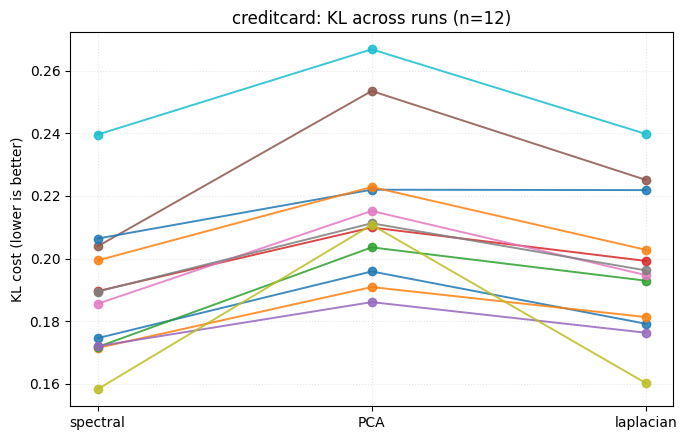

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


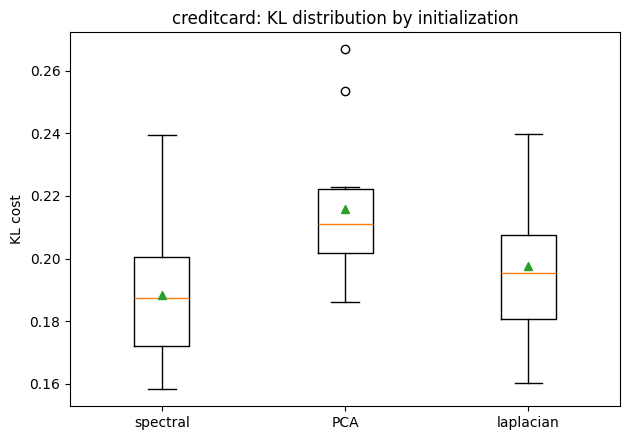

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


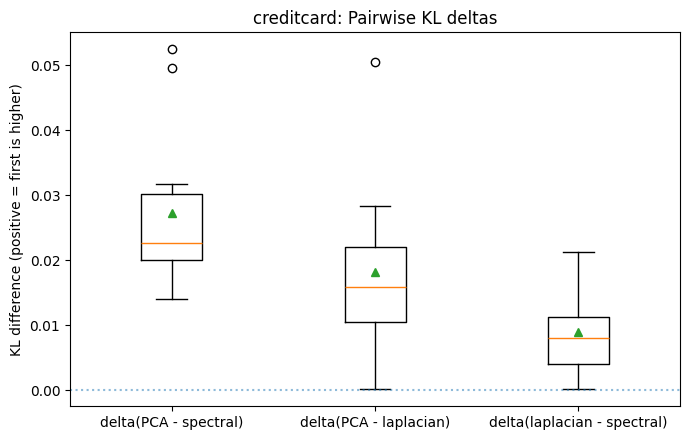

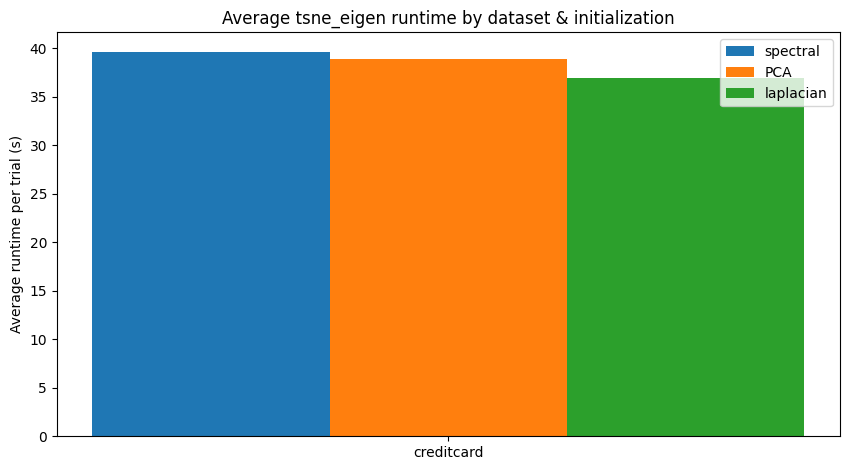

In [30]:
# ============ RUN: CREDIT CARD ============
# Make sure these paths match your machine:
CREDITCARD_CSV = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"

loader_credit = make_creditcard_loader(CREDITCARD_CSV)
X_cc, y_cc = loader_credit()

res_credit = run_many_tsne_comparisons_one_dataset(
    dataset_name="creditcard",
    X=X_cc, y=y_cc,
    n_runs=12,
    sample_size=500,
    pca_components=20,
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={}
)

print(res_credit.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_credit, "creditcard")
plot_boxplots(res_credit, "creditcard")
plot_delta_boxplots(res_credit, "creditcard")

# Bar of mean runtime (works even for single dataset)
plot_time_bar_means(res_credit)

res_credit.to_csv("tsne_creditcard_results.csv", index=False)


In [35]:
import os
import matplotlib.pyplot as plt
import numpy as np

fig_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(fig_dir, exist_ok=True)

# ---------- Paired Lines ----------
def save_paired_lines(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")

    fig, ax = plt.subplots(figsize=(7,4.5))
    for r in pivot.index:
        ax.plot([0,1,2], pivot.loc[r, ["spectral","PCA","laplacian"]], marker="o", alpha=0.85)

    ax.set_xticks([0,1,2], ["spectral","PCA","laplacian"])
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL across runs")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Boxplots ----------
def save_boxplots(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")

    data = [pivot[k].dropna().values for k in ["spectral","PCA","laplacian"]]

    fig, ax = plt.subplots(figsize=(6.4,4.5))
    ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Delta Boxplots ----------
def save_delta_boxplots(res, dataset_name, savepath):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"] == k]["KL"].values for k in keep]

    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.boxplot(data, labels=keep, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference")
    ax.set_title(f"{dataset_name}: Pairwise KL differences")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Runtime Bar ----------
def save_runtime_bar(res, savepath):
    sub = res[res["init"].isin(["spectral","PCA","laplacian"])].dropna(subset=["time_s"])
    means = sub.groupby("init")["time_s"].mean()

    fig, ax = plt.subplots(figsize=(5.5,4.2))
    ax.bar(means.index, means.values)
    ax.set_ylabel("Average runtime (s)")
    ax.set_title("Credit Card: Average runtime by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# --------- SAVE YOUR CREDIT CARD FIGURES ----------
save_paired_lines(res_credit, "creditcard", os.path.join(fig_dir, "creditcard_paired_lines.png"))
save_boxplots(res_credit, "creditcard", os.path.join(fig_dir, "creditcard_boxplot.png"))
save_delta_boxplots(res_credit, "creditcard", os.path.join(fig_dir, "creditcard_delta_boxplot.png"))
save_runtime_bar(res_credit, os.path.join(fig_dir, "creditcard_runtime_bar.png"))

print("Saved:", [f for f in os.listdir(fig_dir) if "creditcard" in f])


C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\3675729671.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\3675729671.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=keep, showmeans=True)


Saved: ['creditcard_boxplot.png', 'creditcard_delta_boxplot.png', 'creditcard_paired_lines.png', 'creditcard_runtime_bar.png']


## IMAGES

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.7013760640591635
Iteration 50: Value of Cost Function is 1.4129094136108478
Iteration 100: Value of Cost Function is 1.2520832828976083
Iteration 150: Value of Cost Function is 1.1801105137605006
Iteration 200: Value of Cost Function is 1.1370125917161022
Iteration 250: Value of Cost Function is 1.107553784346159
Iteration 300: Value of Cost Function is 1.0857479278392694
Iteration 350: Value of Cost Function is 1.0687437426379316
Iteration 400: Value of Cost Function is 1.0549865712815665
Iteration 450: Value of Cost Function is 1.0436360491735481
Iteration 500: Value of Cost Function is 1.034063797686171
Iteration 550:

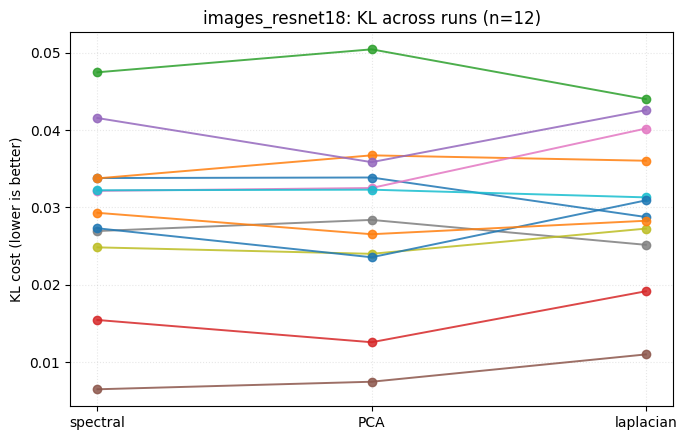

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


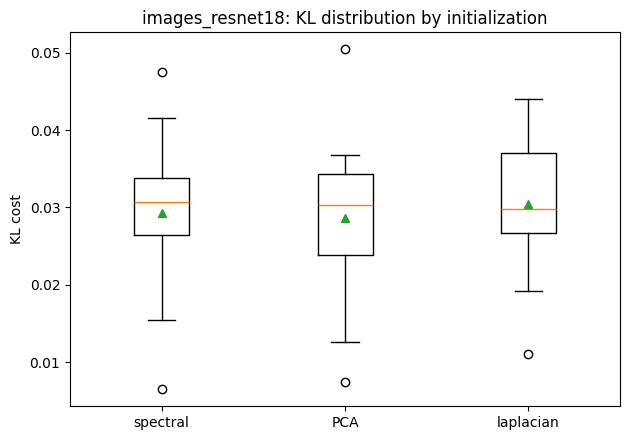

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


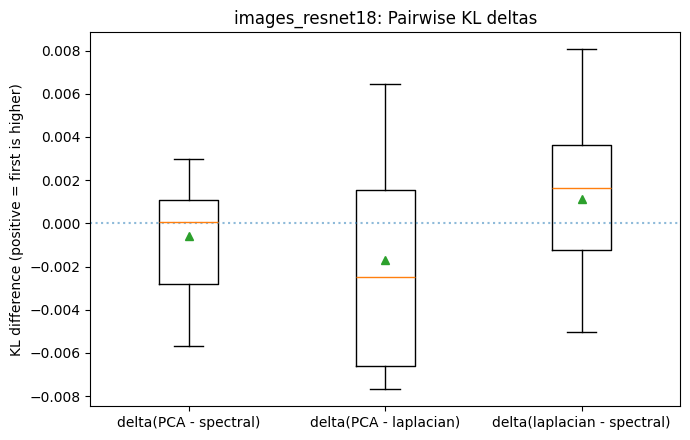

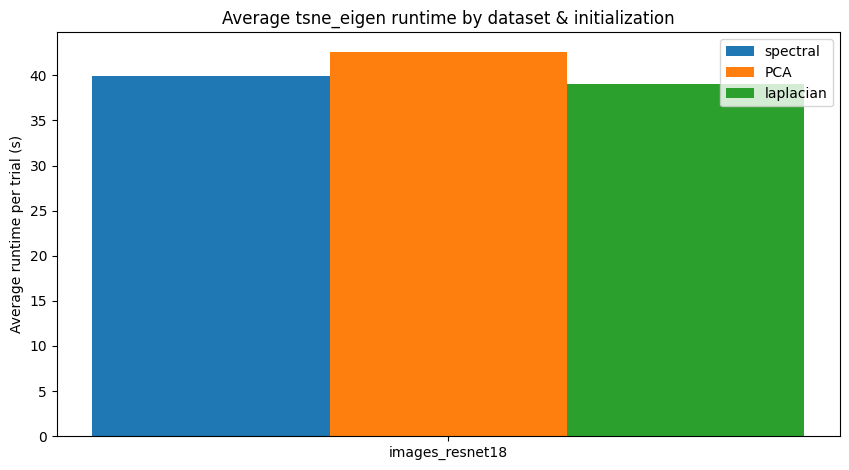

In [14]:
# ============ RUN: IMAGES (ResNet18) ============
TRAIN_DIR  = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\train"
LABELS_CSV = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\trainLabels.csv"

loader_img = make_image_resnet18_loader(TRAIN_DIR, LABELS_CSV, per_class=None, seed=0)
X_img, y_img = loader_img()

# For images, the loader already returns 40-D (PCA) features, so set pca_components=40 or just 20 (it will PCA again).
# To avoid double PCA, set pca_components=40 (no harm) or modify runner to skip PCA if X already has desired dims.
res_images = run_many_tsne_comparisons_one_dataset(
    dataset_name="images_resnet18",
    X=X_img, y=y_img,
    n_runs=12,
    sample_size= 500,   # we've already subsampled per class in the loader
    pca_components=40,            # keep dims; the runner will still standardize+PCA(40)
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={},
    preprocessed_low_dim=True
)

print(res_images.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_images, "images_resnet18")
plot_boxplots(res_images, "images_resnet18")
plot_delta_boxplots(res_images, "images_resnet18")
plot_time_bar_means(res_images)

# Optional: save
res_images.to_csv("tsne_images_results.csv", index=False)


In [36]:
import os
import matplotlib.pyplot as plt
import numpy as np

fig_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(fig_dir, exist_ok=True)

# ---------- Paired Lines ----------
def save_paired_lines(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")

    fig, ax = plt.subplots(figsize=(7,4.5))
    for r in pivot.index:
        ax.plot([0,1,2], pivot.loc[r, ["spectral","PCA","laplacian"]], marker="o", alpha=0.85)

    ax.set_xticks([0,1,2], ["spectral","PCA","laplacian"])
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL across runs")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Boxplots ----------
def save_boxplots(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    data = [pivot[k].dropna().values for k in ["spectral","PCA","laplacian"]]

    fig, ax = plt.subplots(figsize=(6.4,4.5))
    ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Delta Boxplots ----------
def save_delta_boxplots(res, dataset_name, savepath):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"] == k]["KL"].values for k in keep]

    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.boxplot(data, labels=keep, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference")
    ax.set_title(f"{dataset_name}: Pairwise KL differences")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Runtime Bar ----------
def save_runtime_bar(res, savepath):
    sub = res[res["init"].isin(["spectral","PCA","laplacian"])].dropna(subset=["time_s"])
    means = sub.groupby("init")["time_s"].mean()

    fig, ax = plt.subplots(figsize=(5.5,4.2))
    ax.bar(means.index, means.values)
    ax.set_ylabel("Average runtime (s)")
    ax.set_title("Images (ResNet18): Runtime by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- SAVE THEM ----------
save_paired_lines(res_images, "images_resnet18", os.path.join(fig_dir, "images_resnet18_paired_lines.png"))
save_boxplots(res_images, "images_resnet18", os.path.join(fig_dir, "images_resnet18_boxplot.png"))
save_delta_boxplots(res_images, "images_resnet18", os.path.join(fig_dir, "images_resnet18_delta_boxplot.png"))
save_runtime_bar(res_images, os.path.join(fig_dir, "images_resnet18_runtime_bar.png"))

print("Saved:", [f for f in os.listdir(fig_dir) if "images_resnet18" in f])


C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\589308446.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\589308446.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=keep, showmeans=True)


Saved: ['images_resnet18_boxplot.png', 'images_resnet18_delta_boxplot.png', 'images_resnet18_paired_lines.png', 'images_resnet18_runtime_bar.png']


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.7390300379973223
Iteration 50: Value of Cost Function is 1.3145320838650443
Iteration 100: Value of Cost Function is 1.1146934739228058
Iteration 150: Value of Cost Function is 1.021591655291904
Iteration 200: Value of Cost Function is 0.9682538031077688
Iteration 250: Value of Cost Function is 0.9325395386084336
Iteration 300: Value of Cost Function is 0.9064861511582003
Iteration 350: Value of Cost Function is 0.8863969185134986
Iteration 400: Value of Cost Function is 0.8698687395855886
Iteration 450: Value of Cost Function is 0.8565510412789494
Iteration 500: Value of Cost Function is 0.8454573514525627
Iteration 550

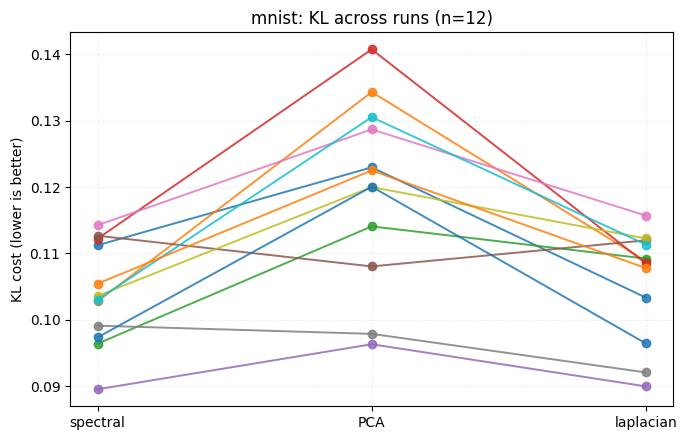

C:\Users\wpbro\AppData\Local\Temp\ipykernel_12684\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


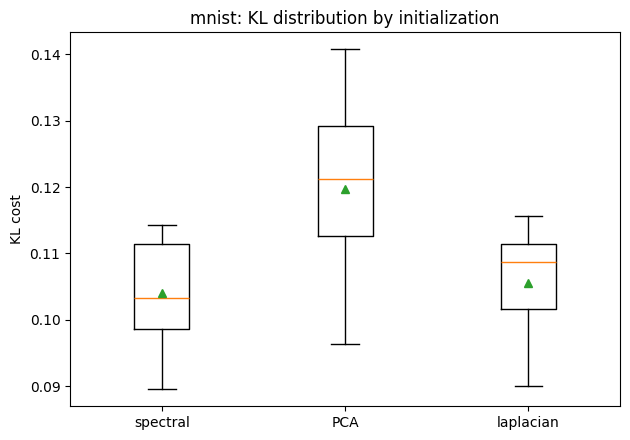

C:\Users\wpbro\AppData\Local\Temp\ipykernel_12684\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


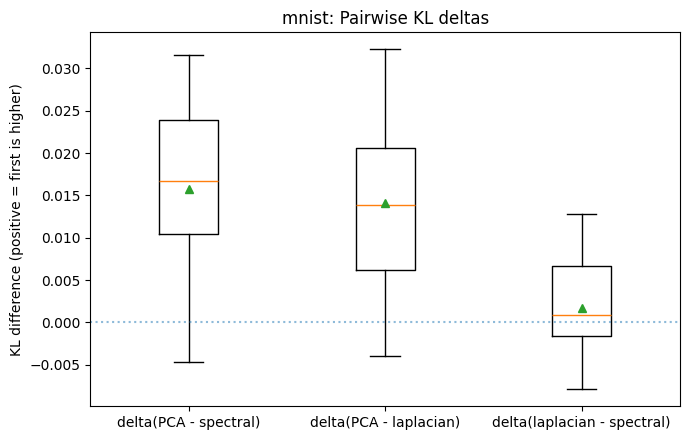

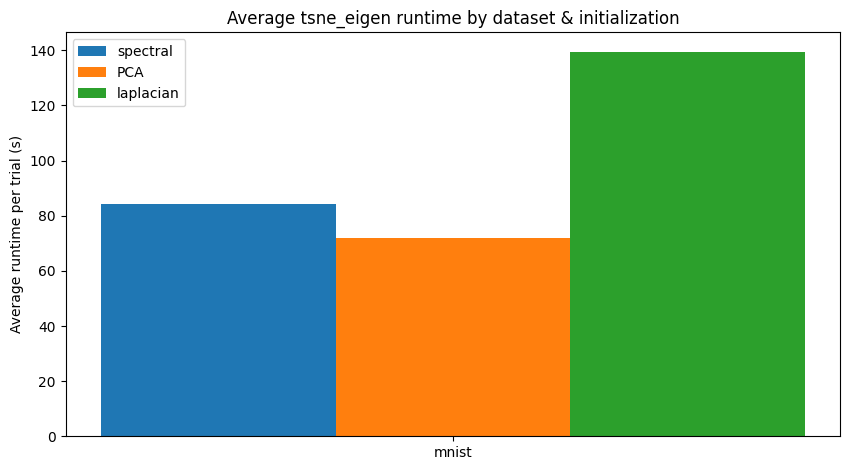

In [5]:
(x_train, y_train), _ = mnist.load_data()

X = x_train.reshape(x_train.shape[0], -1).astype(np.float32) / 255.0
y = y_train.astype(int)

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xp = PCA(n_components=40, random_state=0).fit_transform(Xs)
Xp = normalize(Xp)  # IMPORTANT if you want to match loader behavior

res_mnist = run_many_tsne_comparisons_one_dataset(
    dataset_name="mnist",
    X=Xp, y=y,
    n_runs=12,
    sample_size=500,
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={},
    preprocessed_low_dim=True
)

print(res_mnist.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_mnist, "mnist")
plot_boxplots(res_mnist, "mnist")
plot_delta_boxplots(res_mnist, "mnist")
plot_time_bar_means(res_mnist)

# Optional: save
# res_mnist.to_csv("tsne_mnist_results.csv", index=False)


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Choose your directory (Windows path ok)
fig_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(fig_dir, exist_ok=True)

BASE_INITS = ["spectral", "PCA", "laplacian"]
DELTA_INITS = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]

# ---------- Paired Lines ----------
def save_paired_lines(res, dataset_name, savepath, inits=BASE_INITS, ycol="KL"):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(inits))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values=ycol)

    # Ensure column order
    cols = [k for k in inits if k in pivot.columns]
    if len(cols) < 2:
        raise ValueError(f"Not enough init columns found for {dataset_name}: {pivot.columns.tolist()}")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    xs = np.arange(len(cols))
    for r in pivot.index:
        ax.plot(xs, pivot.loc[r, cols].values, marker="o", alpha=0.85)

    ax.set_xticks(xs, cols)
    ax.set_ylabel("KL cost" if ycol == "KL" else ycol)
    ax.set_title(f"{dataset_name}: {ycol} across runs")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Boxplots ----------
def save_boxplots(res, dataset_name, savepath, inits=BASE_INITS, ycol="KL"):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(inits))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values=ycol)

    cols = [k for k in inits if k in pivot.columns]
    if len(cols) < 2:
        raise ValueError(f"Not enough init columns found for {dataset_name}: {pivot.columns.tolist()}")

    data = [pivot[k].dropna().values for k in cols]

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    ax.boxplot(data, labels=cols, showmeans=True)
    ax.set_ylabel("KL cost" if ycol == "KL" else ycol)
    ax.set_title(f"{dataset_name}: {ycol} distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Delta Boxplots ----------
def save_delta_boxplots(res, dataset_name, savepath, delta_inits=DELTA_INITS, ycol="KL"):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(delta_inits))].copy()

    # If your res_mnist doesn't include delta rows, this will be empty.
    if sub.empty:
        print(f"[skip] No delta rows found for {dataset_name}. (This is ok if you didn't compute deltas.)")
        return

    data = [sub[sub["init"] == k][ycol].dropna().values for k in delta_inits]
    labels = [k for k in delta_inits]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(data, labels=labels, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference" if ycol == "KL" else ycol)
    ax.set_title(f"{dataset_name}: Pairwise {ycol} differences")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ---------- Runtime Bar ----------
def save_runtime_bar(res, dataset_name, savepath, inits=BASE_INITS, timecol="time_s"):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(inits))].dropna(subset=[timecol])
    if sub.empty:
        print(f"[skip] No runtime data found for {dataset_name} in column '{timecol}'.")
        return

    means = sub.groupby("init")[timecol].mean()
    means = means.reindex([k for k in inits if k in means.index])

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    ax.bar(means.index, means.values)
    ax.set_ylabel("Average runtime (s)")
    ax.set_title(f"{dataset_name}: Average runtime by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# --------- SAVE YOUR MNIST FIGURES ----------
save_paired_lines(res_mnist, "mnist", os.path.join(fig_dir, "mnist_paired_lines.png"))
save_boxplots(res_mnist, "mnist", os.path.join(fig_dir, "mnist_boxplot.png"))
save_delta_boxplots(res_mnist, "mnist", os.path.join(fig_dir, "mnist_delta_boxplot.png"))
save_runtime_bar(res_mnist, "mnist", os.path.join(fig_dir, "mnist_runtime_bar.png"))

print("Saved MNIST:", [f for f in os.listdir(fig_dir) if "mnist" in f.lower()])

C:\Users\wpbro\AppData\Local\Temp\ipykernel_12684\2780687217.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=cols, showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_12684\2780687217.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


Saved MNIST: ['mnist_boxplot.png', 'MNIST_Dataset_first_10_images.png', 'mnist_delta_boxplot.png', 'mnist_paired_lines.png', 'mnist_runtime_bar.png', 't-SNE_cost_function_comparison_box_plot_for _MNIST_no_grad.png', 't-SNE_cost_function_comparison_deltas_boxplot_for_MNIST_dataset.png', 't-SNE_cost_function_comparison_delta_box_plot_for _MNIST_no_grad.png', 't-SNE_cost_function_comparison_for_MNIST_dataset.png', 't-SNE_cost_function_comparison_line_graph_for _MNIST_no_grad.png', 't-SNE_cost_function_comparison_line_graph_for_MNIST_dataset.png', 't-SNE_cost_function_comparison_runtime_for _MNIST_no_grad.png', 't-SNE_cost_function_comparison_runtime_for_MNIST_dataset.png', 't-SNE_Laplacian_Initialization_Embedding_for_MNIST_dataset_without_gradient_descent.png', 't-SNE_Laplacian_Initialization_embedding_for_MNIST_dataset_with_gradient_descent.png', 't-SNE_on_the_MNIST_dataset.png', 't-SNE_PCA_initialization_embedding_on_MNIST_dataset-without-gradient_descent.png', 't-SNE_PCA_initializatio

## RNA

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.32123640224866
Iteration 50: Value of Cost Function is 1.8708446898302262
Iteration 100: Value of Cost Function is 1.8245643429489298
Iteration 150: Value of Cost Function is 1.805522119975851
Iteration 200: Value of Cost Function is 1.7936962061856194
Iteration 250: Value of Cost Function is 1.78556961458355
Iteration 300: Value of Cost Function is 1.7794444659375237
Iteration 350: Value of Cost Function is 1.7746849138964764
Iteration 400: Value of Cost Function is 1.770817296707095
Iteration 450: Value of Cost Function is 1.7676148176363915
Iteration 500: Value of Cost Function is 1.7648753922890816
Iteration 550: Val

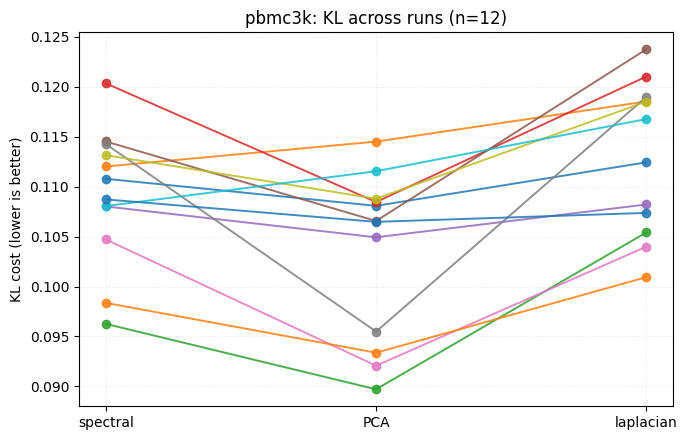

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


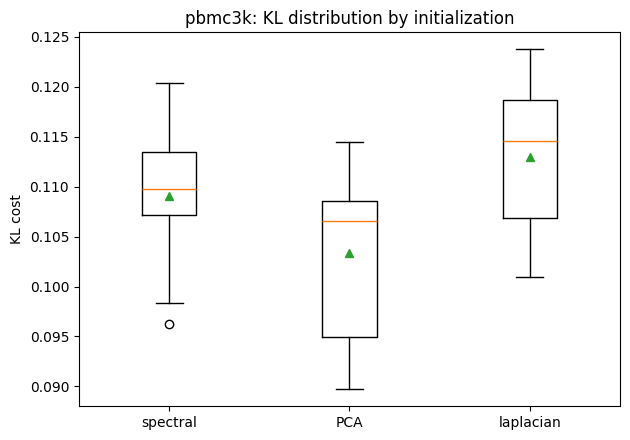

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


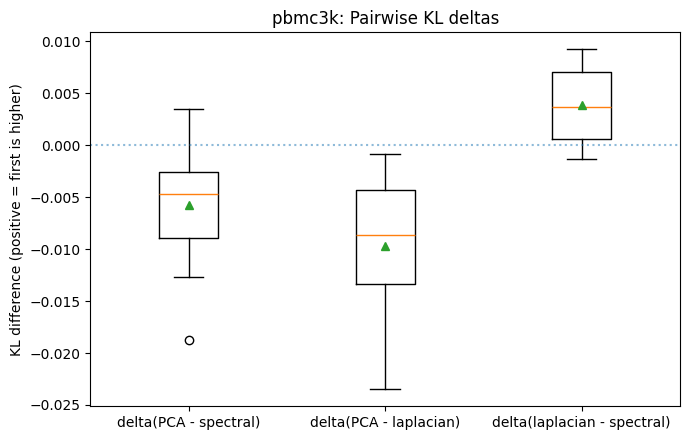

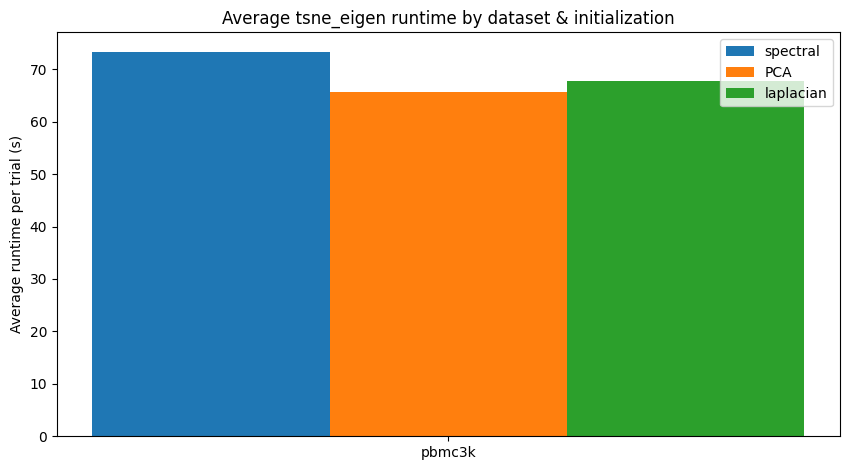

In [26]:
# ============ RUN: PBMC3k (scRNA-seq) ============
loader_pbmc = make_pbmc3k_loader(n_cells_per_run=500, seed=0)
X_pbmc, y_pbmc = loader_pbmc()

res_pbmc = run_many_tsne_comparisons_one_dataset(
    dataset_name="pbmc3k",
    X=X_pca_rna, y=labels,
    n_runs=12,
    sample_size=500,      # already 500 per loader call, but this keeps API consistent
    pca_components=40,    # X already in PCA(40) from Scanpy; PCA again is okay but you can keep 40
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={}
)

print(res_pbmc.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_pbmc, "pbmc3k")
plot_boxplots(res_pbmc, "pbmc3k")
plot_delta_boxplots(res_pbmc, "pbmc3k")
plot_time_bar_means(res_pbmc)

# Optional: save
res_pbmc.to_csv("tsne_pbmc3k_results.csv", index=False)


In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt

fig_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(fig_dir, exist_ok=True)

def save_paired_lines(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    runs = sorted(pivot.index)
    x_positions = [0, 1, 2]
    labels = ["spectral", "PCA", "laplacian"]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for r in runs:
        yvals = [pivot.loc[r, k] for k in labels]
        ax.plot(x_positions, yvals, marker="o", alpha=0.85, linewidth=1.4)

    ax.set_xticks(x_positions, labels)
    ax.set_ylabel("KL cost (lower is better)")
    ax.set_title(f"{dataset_name}: KL across runs (n={len(runs)})")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_boxplots(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    data = [
        pivot["spectral"].dropna().values,
        pivot["PCA"].dropna().values,
        pivot["laplacian"].dropna().values
    ]

    fig, ax = plt.subplots(figsize=(6.4, 4.5))
    ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_delta_boxplots(res, dataset_name, savepath):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"] == k]["KL"].values for k in keep]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.boxplot(data, labels=keep, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference (positive = first is higher)")
    ax.set_title(f"{dataset_name}: Pairwise KL deltas")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_time_bar_means(res, savepath):
    sub = res[res["init"].isin(["spectral","PCA","laplacian"])].dropna(subset=["time_s"])
    means = sub.groupby(["dataset","init"], as_index=False)["time_s"].mean()

    datasets = list(means["dataset"].unique())
    inits = ["spectral","PCA","laplacian"]
    x = np.arange(len(datasets))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    for j, init in enumerate(inits):
        y_vals = []
        for d in datasets:
            row = means[(means["dataset"] == d) & (means["init"] == init)]
            y_vals.append(float(row["time_s"].values[0]) if len(row) else np.nan)
        ax.bar(x + j*width - width, y_vals, width, label=init)

    ax.set_xticks(x, datasets)
    ax.set_ylabel("Average runtime per trial (s)")
    ax.set_title("Average tsne_eigen runtime by dataset & initialization")
    ax.legend()
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# --- Save PBMC figures (no re-running t-SNE) ---
save_paired_lines(res_pbmc, "pbmc3k", os.path.join(fig_dir, "pbmc3k_paired_lines.png"))
save_boxplots(res_pbmc, "pbmc3k", os.path.join(fig_dir, "pbmc3k_boxplot.png"))
save_delta_boxplots(res_pbmc, "pbmc3k", os.path.join(fig_dir, "pbmc3k_delta_boxplot.png"))
save_time_bar_means(res_pbmc, os.path.join(fig_dir, "pbmc3k_time_bar_means.png"))

print("Saved files:", [f for f in os.listdir(fig_dir) if f.endswith(".png")])


C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\107231634.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\107231634.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=keep, showmeans=True)


Saved files: ['MNIST Dataset first 10 images.png', 'pbmc3k_boxplot.png', 'pbmc3k_delta_boxplot.png', 'pbmc3k_paired_lines.png', 'pbmc3k_time_bar_means.png', 't-SNE cost function comparison box plots for Credit Card data.png', 't-SNE cost function comparison deltas boxplot for MNIST dataset.png', 't-SNE cost function comparison for MNIST dataset.png', 't-SNE cost function comparison line graph for Credit card data.png', 't-SNE cost function comparison line graph for MNIST dataset.png', 't-SNE cost function comparison runtime for MNIST dataset.png', 't-SNE Laplacian Initialization embedding for MNIST dataset with gradient descent.png', 't-SNE Laplacian Initialization Embedding for MNIST dataset without gradient descent.png', 't-SNE on the mNIST dataset.png', 't-SNE PCA initialization embedding on COIL-20 dataset with gradient descent.png', 't-SNE PCA initialization embedding on COIL-20 dataset without gradient descent.png', 't-SNE PCA Initialization embedding on Credit Card Dataset with 

In [28]:
# ============ RUN: PBMC3k (scRNA-seq) ============
loader_pbmc = make_pbmc3k_loader(n_cells_per_run=500, seed=0)
X_pbmc, y_pbmc = loader_pbmc()

res_pbmc = run_many_tsne_comparisons_one_dataset(
    dataset_name="pbmc3k",
    X=X_pbmc, y=y_pbmc,
    n_runs=12,
    sample_size=500,      # already 500 per loader call, but this keeps API consistent
    pca_components=40,    # X already in PCA(40) from Scanpy; PCA again is okay but you can keep 40
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={}
)

print(res_pbmc.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_pbmc, "pbmc3k")
plot_boxplots(res_pbmc, "pbmc3k")
plot_delta_boxplots(res_pbmc, "pbmc3k")
plot_time_bar_means(res_pbmc)

# Optional: save
res_pbmc.to_csv("tsne_pbmc3k_results(1).csv", index=False)

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.3262446950962166
Iteration 50: Value of Cost Function is 1.8846904652199414
Iteration 100: Value of Cost Function is 1.8348362824109987
Iteration 150: Value of Cost Function is 1.8125602538348449
Iteration 200: Value of Cost Function is 1.7994251609535885
Iteration 250: Value of Cost Function is 1.7902791770734834
Iteration 300: Value of Cost Function is 1.7819580894538527
Iteration 350: Value of Cost Function is 1.7752490299091104
Iteration 400: Value of Cost Function is 1.769621942648397
Iteration 450: Value of Cost Function is 1.765150720487129
Iteration 500: Value of Cost Function is 1.761527657585081
Iteration 550: 

KeyboardInterrupt: 

# NOT WORKING

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.562244667235575
Iteration 50: Value of Cost Function is 1.401653613266135
Iteration 100: Value of Cost Function is 1.2228299770571671
Iteration 150: Value of Cost Function is 1.138677368762736
Iteration 200: Value of Cost Function is 1.087734589334214
Iteration 250: Value of Cost Function is 1.0526296169231815
Iteration 300: Value of Cost Function is 1.0265565664015157
Iteration 350: Value of Cost Function is 1.0062410514163298
Iteration 400: Value of Cost Function is 0.989807529918172
Iteration 450: Value of Cost Function is 0.9759611289325325
Iteration 500: Value of Cost Function is 0.9643152324280754
Iteration 550: Va

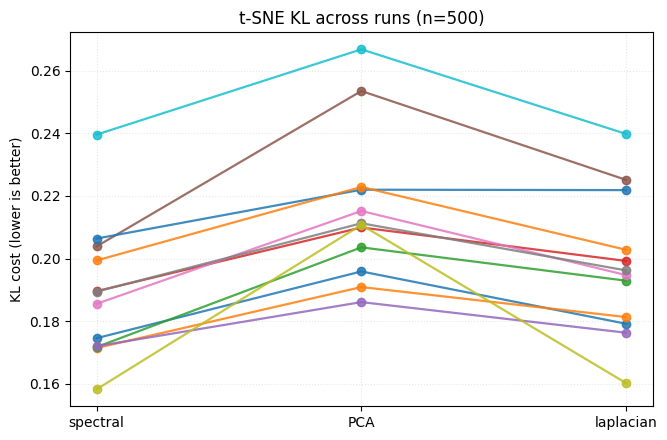

C:\Users\wpbro\AppData\Local\Temp\ipykernel_26964\3219347275.py:150: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


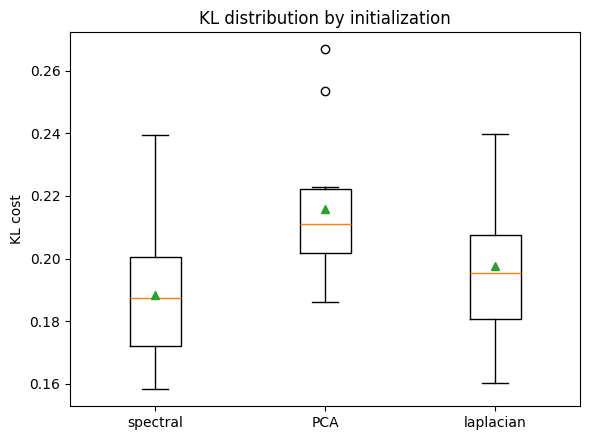

Figures saved to: C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures


In [ ]:
# ===============================
# Helpers to compute t-SNE KL
# ===============================
def _Hbeta(D_row, beta):
    P = np.exp(-D_row * beta)
    P[0] = 0.0
    sumP = P.sum()
    if sumP <= 1e-12:
        return 0.0, P
    P /= sumP
    H = -np.sum(P * np.log2(P + 1e-12))
    return H, P

def _binary_search_perplexity(D_row, target_perp=30.0, tol=1e-5, max_iter=50):
    logU = np.log2(target_perp)
    beta = 1.0
    betamin, betamax = -np.inf, np.inf
    H, P = _Hbeta(D_row, beta)
    it = 0
    while abs(H - logU) > tol and it < max_iter:
        if H > logU:
            betamin = beta
            beta = beta * 2 if not np.isfinite(betamax) else (beta + betamax) / 2
        else:
            betamax = beta
            beta = beta / 2 if not np.isfinite(betamin) else (beta + betamin) / 2
        H, P = _Hbeta(D_row, beta)
        it += 1
    return P

def tsne_joint_probabilities(X, perplexity=30.0):
    # squared distances
    sum_X = np.sum(np.square(X), axis=1)
    D = sum_X[:, None] + sum_X[None, :] - 2 * X @ X.T
    np.maximum(D, 0, out=D)
    N = X.shape[0]
    P = np.zeros((N, N), dtype=np.float64)
    for i in range(N):
        Pi = _binary_search_perplexity(D[i].copy(), target_perp=perplexity)
        P[i] = Pi
    P = (P + P.T)
    P /= max(P.sum(), 1e-12)
    np.fill_diagonal(P, 0.0)
    return P

def tsne_q_from_Y(Y):
    sum_Y = np.sum(np.square(Y), axis=1)
    dist = sum_Y[:, None] + sum_Y[None, :] - 2 * Y @ Y.T
    num = 1.0 / (1.0 + np.maximum(dist, 0))
    np.fill_diagonal(num, 0.0)
    Q = num / max(num.sum(), 1e-12)
    return Q

def tsne_kl(P, Q):
    eps = 1e-12
    return float(np.sum(P * (np.log(P + eps) - np.log(Q + eps))))

# ===============================
# Experiment runner
# ===============================
def run_many_tsne_comparisons(X, y, n_runs=12, sample_size=500, pca_components=20,
                              perplexity=30.0, T=1000):
    scaler = StandardScaler()
    pca = PCA(n_components=pca_components, random_state=0)

    rows = []
    for seed in range(n_runs):
        # stratified sample of 'sample_size' rows
        sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=seed)
        idx_sample, _ = next(sss.split(X, y))
        Xs = X[idx_sample]
        ys = y[idx_sample]

        # scale → PCA (these are the high-D features for affinities)
        Xp = pca.fit_transform(scaler.fit_transform(Xs))

        # build P once per sample (same P for both inits)
        P = tsne_joint_probabilities(Xp, perplexity=perplexity)

        # --- your t-SNE, two inits ---
        Y_spec = tsne_eigen(Xp, initialization_method="spectral", T=T)
        Y_pca  = tsne_eigen(Xp, initialization_method="PCA", T=T)
        Y_lap  = tsne_eigen(Xp, initialization_method="laplacian", T=T)

        # If your function can return final KL internally, replace the two lines below with that value.
        Q_spec = tsne_q_from_Y(Y_spec);  kl_spec = tsne_kl(P, Q_spec)
        Q_pca  = tsne_q_from_Y(Y_pca);   kl_pca  = tsne_kl(P, Q_pca)
        Q_lap  = tsne_q_from_Y(Y_lap);   kl_lap  = tsne_kl(P, Q_lap)

        rows.append({"run": seed, "init": "spectral", "KL": kl_spec})
        rows.append({"run": seed, "init": "PCA",      "KL": kl_pca})
        rows.append({"run": seed, "init": "laplacian",      "KL": kl_lap})
        rows.append({"run": seed, "init": "delta(PCA - spectral)", "KL": kl_pca - kl_spec})
        rows.append({"run": seed, "init": "delta(PCA - laplacian)", "KL": kl_pca - kl_lap})
        rows.append({"run": seed, "init": "delta(laplacian - spectral)", "KL": kl_lap - kl_spec})

    res = pd.DataFrame(rows)
    return res


DATA_PATH = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"
df = pd.read_csv(DATA_PATH)
y = df["Class"].values
X = df.drop(columns=["Class"]).values

res = run_many_tsne_comparisons(
    X, y,
    n_runs=12,
    sample_size=500,
    pca_components=20,
    perplexity=30.0,
    T=1000
)

# Table view (paired per run)
pivot = res[res["init"].isin(["spectral","PCA","laplacian"])] \
           .pivot_table(index="run", columns="init", values="KL") \
           .sort_index()
print(pivot)

# -------- Paired-lines viz (3 points per run) --------
runs = list(pivot.index)
x = [0, 1, 2]  # spectral, PCA, laplacian (match order below)
order = ["spectral", "PCA", "laplacian"]

out_dir = Path("results_figures")
out_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6.8, 4.5))
for r in runs:
    yvals = [pivot.loc[r, k] for k in order]
    plt.plot(x, yvals, marker='o', alpha=0.85, linewidth=1.6)
plt.xticks(x, order)
plt.ylabel("KL cost (lower is better)")
plt.title("t-SNE KL across runs (n=500)")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

plt.savefig(out_dir / "tsne_kl_paired.jpg", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "tsne_kl_paired.pdf", bbox_inches="tight")  # optional vector version
plt.close()

# -------- Boxplot summary (3-way) --------
kl_spec = pivot["spectral"].dropna().values
kl_pca  = pivot["PCA"].dropna().values
kl_lap  = pivot["laplacian"].dropna().values

plt.figure(figsize=(6.0, 4.5))
plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)
plt.ylabel("KL cost")
plt.title("KL distribution by initialization")
plt.tight_layout()
plt.show()

plt.savefig(out_dir / "tsne_kl_boxplot.jpg", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "tsne_kl_boxplot.pdf", bbox_inches="tight")
plt.close()

print(f"Figures saved to: {out_dir.resolve()}")

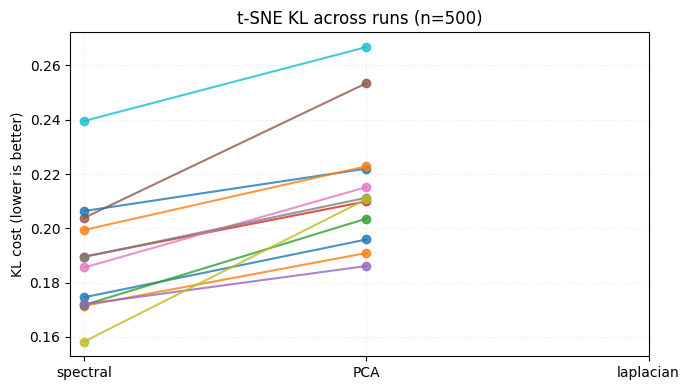

C:\Users\wpbro\AppData\Local\Temp\ipykernel_37360\3917325925.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


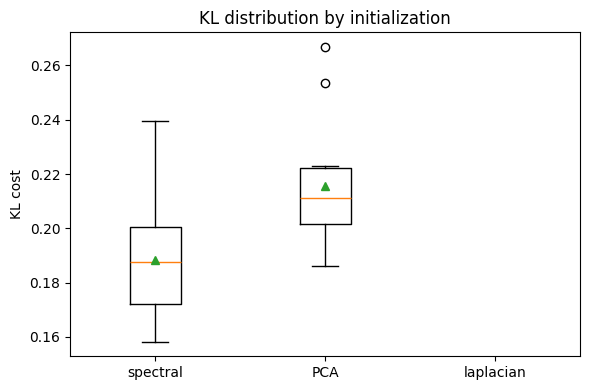

In [ ]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

def laplacian_init(X, n_neighbors=15, weight="heat", sigma=None, random_state=0):
    """
    Compute a 2D Laplacian Eigenmaps embedding for initialization.
    X: (n_samples, n_features) AFTER your scaling/PCA (same Xp you use for P).
    Returns Y0: (n_samples, 2)
    """
    rng = np.random.RandomState(random_state)
    n = X.shape[0]

    # Build kNN graph
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1, algorithm="auto").fit(X)
    dists, inds = nbrs.kneighbors(X)               # dists[:, 0] = 0 to self
    inds = inds[:, 1:]                             # drop self
    dists = dists[:, 1:]

    # Choose weights
    if weight == "heat":
        # pick sigma if not provided: median of neighbor distances
        if sigma is None:
            sigma = np.median(dists)
            if not np.isfinite(sigma) or sigma <= 0:
                sigma = 1.0
        W_vals = np.exp(-(dists**2) / (2.0 * sigma**2))
    elif weight == "binary":
        W_vals = np.ones_like(dists)
    else:
        raise ValueError("weight must be 'heat' or 'binary'")

    # Build symmetric sparse W
    rows = np.repeat(np.arange(n), inds.shape[1])
    cols = inds.reshape(-1)
    data = W_vals.reshape(-1)
    W = csr_matrix((data, (rows, cols)), shape=(n, n))
    W = 0.5 * (W + W.T)                            # symmetrize

    # Normalized Laplacian: L = I - D^{-1/2} W D^{-1/2}
    d = np.asarray(W.sum(axis=1)).ravel()
    d_safe = np.where(d > 1e-12, d, 1e-12)
    D_inv_sqrt = diags(1.0 / np.sqrt(d_safe))
    L = csr_matrix(np.eye(n)) - D_inv_sqrt @ W @ D_inv_sqrt

    # Smallest nontrivial eigenvectors (skip the constant one)
    # Ask for 3 and drop the first; keep next two for 2D
    vals, vecs = eigsh(L, k=3, which="SM")
    order = np.argsort(vals)
    vecs = vecs[:, order]
    Y0 = vecs[:, 1:3]                               # drop constant eigenvector

    # Scale to the same tiny scale t-SNE typically expects (like PCA init)
    Y0 = Y0 / (np.std(Y0) + 1e-12) * 1e-4
    return Y0

def run_tsne_with_init(Xp, init, T, random_state):
    if init in ("spectral", "PCA"):
        return tsne_eigen(Xp, initialization_method=init, T=T, random_state=random_state)

    if init == "laplacian":
        # 1) try native support
        try:
            return tsne_eigen(Xp, initialization_method="laplacian", T=T, random_state=random_state)
        except TypeError:
            pass
        # 2) compute Y0 and try passing it directly
        Y0 = laplacian_init(Xp, n_neighbors=15, weight="heat", sigma=None, random_state=random_state)
        try:
            return tsne_eigen(Xp, Y0=Y0, T=T, random_state=random_state)
        except TypeError:
            # 3) or via a 'custom' flag if your function uses that
            return tsne_eigen(Xp, initialization_method="custom", Y0=Y0, T=T, random_state=random_state)

    raise ValueError(f"Unknown init: {init}")

def run_many_tsne_comparisons(X, y, n_runs=12, sample_size=500, pca_components=20,
                              perplexity=30.0, T=1000, inits=("spectral","PCA","laplacian")):
    scaler = StandardScaler()
    pca = PCA(n_components=pca_components, random_state=0)

    rows = []
    for seed in range(n_runs):
        # stratified sample of 'sample_size' rows
        sss = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=seed)
        idx_sample, _ = next(sss.split(X, y))
        Xs = X[idx_sample]
        ys = y[idx_sample]

        # scale → PCA (these are the high-D features for affinities)
        Xp = pca.fit_transform(scaler.fit_transform(Xs))

        # build P once per sample (same P for all inits)
        P = tsne_joint_probabilities(Xp, perplexity=perplexity)

        # run all requested inits and store KL
        kl_by_init = {}
        for init in inits:
            Y = run_tsne_with_init(Xp, init=init, T=T, random_state=seed)
            Q = tsne_q_from_Y(Y)
            kl = tsne_kl(P, Q)
            kl_by_init[init] = kl
            rows.append({"run": seed, "init": init, "KL": kl})

        # add deltas vs spectral (if spectral present)
        if "spectral" in kl_by_init:
            base = kl_by_init["spectral"]
            for init in inits:
                if init == "spectral": 
                    continue
                rows.append({"run": seed, "init": f"delta({init} - spectral)", "KL": kl_by_init[init] - base})

    res = pd.DataFrame(rows)
    return res

core = res[res["init"].isin(["spectral","PCA","laplacian"])].copy()
order = ["spectral","PCA","laplacian"]
runs = sorted(core["run"].unique())
kl_mat = np.vstack([
    core[core["run"]==r].set_index("init").reindex(order)["KL"].values
    for r in runs
])

plt.figure(figsize=(7,4))
for i in range(len(runs)):
    plt.plot(range(len(order)), kl_mat[i], marker='o', alpha=0.8)
plt.xticks(range(len(order)), order)
plt.ylabel("KL cost (lower is better)")
plt.title("t-SNE KL across runs (n=500)")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
data = [core[core["init"]==k]["KL"].values for k in order]
plt.boxplot(data, labels=order, showmeans=True)
plt.ylabel("KL cost")
plt.title("KL distribution by initialization")
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np

# --- helpers (same as before) ---
def _Hbeta(D_row, beta):
    P = np.exp(-D_row * beta); P[0] = 0.0
    s = P.sum()
    if s <= 1e-12: return 0.0, P
    P /= s
    H = -np.sum(P * np.log2(P + 1e-12))
    return H, P

def _binary_search_perplexity(D_row, target_perp=30.0, tol=1e-5, max_iter=50):
    logU = np.log2(target_perp); beta = 1.0
    lo, hi = -np.inf, np.inf
    H, P = _Hbeta(D_row, beta); it = 0
    while abs(H - logU) > tol and it < max_iter:
        if H > logU:
            lo = beta; beta = beta*2 if not np.isfinite(hi) else (beta+hi)/2
        else:
            hi = beta; beta = beta/2 if not np.isfinite(lo) else (beta+lo)/2
        H, P = _Hbeta(D_row, beta); it += 1
    return P

def tsne_joint_probabilities(X, perplexity=30.0):
    s = np.sum(X**2, axis=1)
    D = s[:,None] + s[None,:] - 2*X@X.T
    np.maximum(D, 0, out=D)
    N = X.shape[0]; P = np.zeros((N,N), dtype=np.float64)
    for i in range(N):
        P[i] = _binary_search_perplexity(D[i].copy(), target_perp=perplexity)
    P = (P + P.T)
    P /= max(P.sum(), 1e-12)
    np.fill_diagonal(P, 0.0)
    return P

def tsne_q_from_Y(Y):
    s = np.sum(Y**2, axis=1)
    D = s[:,None] + s[None,:] - 2*Y@Y.T
    num = 1.0/(1.0 + np.maximum(D, 0))
    np.fill_diagonal(num, 0.0)
    return num / max(num.sum(), 1e-12)

def tsne_kl(P, Q):
    eps = 1e-12
    return float(np.sum(P * (np.log(P + eps) - np.log(Q + eps))))

# --- build P once from the exact features you give tsne_eigen ---
PERP = 30.0
P = tsne_joint_probabilities(X_pca_rna, perplexity=PERP)

# --- run your t-SNE twice with different inits (increase T for fairness) ---
T_ITERS = 1000  # e.g., 1000
Y_spec = tsne_eigen(X_pca_rna, initialization_method="spectral", T=T_ITERS)
Y_pca  = tsne_eigen(X_pca_rna, initialization_method="PCA",      T=T_ITERS)

# --- compute KL against the same P ---
KL_spec = tsne_kl(P, tsne_q_from_Y(Y_spec))
KL_pca  = tsne_kl(P, tsne_q_from_Y(Y_pca))

print(f"KL (spectral): {KL_spec:.6f}")
print(f"KL (PCA)     : {KL_pca:.6f}")
print(f"Δ KL (PCA - spectral): {KL_pca - KL_spec:.6f}")



Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.9644672170688695
Iteration 50: Value of Cost Function is 3.6342259842967404
Iteration 100: Value of Cost Function is 3.3575478987382414
Iteration 150: Value of Cost Function is 3.1927304464995543
Iteration 200: Value of Cost Function is 3.110520776293318
Iteration 250: Value of Cost Function is 3.059413198433249
Iteration 300: Value of Cost Function is 3.0231405316025795
Iteration 350: Value of Cost Function is 2.995335008240526
Iteration 400: Value of Cost Function is 2.9729736290705917
Iteration 450: Value of Cost Function is 2.9543342902954937
Iteration 500: Value of Cost Function is 2.9384502306762297
Iteration 550: 

In [ ]:
# --- Laplacian Eigenmaps init (2D) ---
# Requires: sklearn + scipy. If scipy.sparse.linalg.eigsh is unavailable,
# it falls back to dense np.linalg.eigh (OK for a few hundred points).
from sklearn.neighbors import NearestNeighbors

def laplacian_init(X, n_neighbors=15, weight="heat", sigma=None, random_state=0):
    """
    X: features you feed to tsne_eigen (e.g., X_pca_rna)
    Returns a small-scale 2D initialization (n_samples, 2).
    """
    import numpy as _np
    rng = _np.random.RandomState(random_state)
    n = X.shape[0]

    # kNN graph
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    dists, inds = nbrs.kneighbors(X)
    inds = inds[:, 1:]     # drop self
    dists = dists[:, 1:]

    # weights
    if weight == "heat":
        if sigma is None:
            sigma = _np.median(dists) if _np.isfinite(_np.median(dists)) and _np.median(dists) > 0 else 1.0
        W_vals = _np.exp(-(dists**2) / (2.0 * sigma**2))
    elif weight == "binary":
        W_vals = _np.ones_like(dists)
    else:
        raise ValueError("weight must be 'heat' or 'binary'")

    # build symmetric W (dense is fine for ~500 points)
    W = _np.zeros((n, n), dtype=float)
    rows = _np.repeat(_np.arange(n), inds.shape[1])
    cols = inds.reshape(-1)
    W[rows, cols] = W_vals.reshape(-1)
    W = 0.5 * (W + W.T)

    # normalized Laplacian: L = I - D^{-1/2} W D^{-1/2}
    d = W.sum(axis=1)
    d_safe = _np.where(d > 1e-12, d, 1e-12)
    Dm12 = 1.0 / _np.sqrt(d_safe)
    L = _np.eye(n) - (Dm12[:, None] * W * Dm12[None, :])

    # eigendecomposition: take two smallest nontrivial eigenvectors
    try:
        from scipy.sparse import csr_matrix, diags
        from scipy.sparse.linalg import eigsh
        Ls = csr_matrix(L)
        vals, vecs = eigsh(Ls, k=3, which="SM")
        order = _np.argsort(vals)
        Y0 = vecs[:, order][:, 1:3]
    except Exception:
        # dense fallback
        vals, vecs = _np.linalg.eigh(L)
        order = _np.argsort(vals)
        Y0 = vecs[:, order][:, 1:3]

    # t-SNE-friendly scale
    Y0 = Y0 / (Y0.std() + 1e-12) * 1e-4
    return Y0

def run_tsne_with_init(X_feat, init, T, random_state=0):
    if init in ("spectral", "PCA"):
        return tsne_eigen(X_feat, initialization_method=init, T=T)

    if init == "laplacian":
        # try native support first
        try:
            return tsne_eigen(X_feat, initialization_method="laplacian", T=T)
        except TypeError:
            pass
        # compute Y0 and pass it
        Y0 = laplacian_init(X_feat, n_neighbors=15, weight="heat", sigma=None, random_state=random_state)
        try:
            return tsne_eigen(X_feat, Y0=Y0, T=T)
        except TypeError:
            return tsne_eigen(X_feat, initialization_method="custom", Y0=Y0, T=T)

    raise ValueError(f"Unknown init: {init}")


# --- build P once from the exact features you give tsne_eigen ---
PERP = 30.0
P = tsne_joint_probabilities(X_pca_rna, perplexity=PERP)

# --- run your t-SNE with three inits (keep same T for fairness) ---
T_ITERS = 1000
Y_spec = run_tsne_with_init(X_pca_rna, "spectral",  T=T_ITERS, random_state=0)
Y_pca  = run_tsne_with_init(X_pca_rna, "PCA",       T=T_ITERS, random_state=0)
Y_lap  = run_tsne_with_init(X_pca_rna, "laplacian", T=T_ITERS, random_state=0)

# --- compute KL against the same P ---
KL_spec = tsne_kl(P, tsne_q_from_Y(Y_spec))
KL_pca  = tsne_kl(P, tsne_q_from_Y(Y_pca))
KL_lap  = tsne_kl(P, tsne_q_from_Y(Y_lap))

print(f"KL (spectral) : {KL_spec:.6f}")
print(f"KL (PCA)      : {KL_pca:.6f}")
print(f"KL (laplacian): {KL_lap:.6f}")
print(f"Δ KL (PCA - spectral)      : {KL_pca - KL_spec:.6f}")
print(f"Δ KL (laplacian - spectral): {KL_lap - KL_spec:.6f}")


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.9644672170688695
Iteration 50: Value of Cost Function is 3.6342259842967404
Iteration 100: Value of Cost Function is 3.3575478987382414
Iteration 150: Value of Cost Function is 3.1927304464995543
Iteration 200: Value of Cost Function is 3.110520776293318
Iteration 250: Value of Cost Function is 3.059413198433249
Iteration 300: Value of Cost Function is 3.0231405316025795
Iteration 350: Value of Cost Function is 2.995335008240526
Iteration 400: Value of Cost Function is 2.9729736290705917
Iteration 450: Value of Cost Function is 2.9543342902954937
Iteration 500: Value of Cost Function is 2.9384502306762297
Iteration 550: 

In [ ]:
import numpy as np, pandas as pd

def sample_cells(adata, n=500, seed=0, stratify_by=None):
    rng = np.random.default_rng(seed)
    if stratify_by is None:
        idx = rng.choice(adata.n_obs, size=min(n, adata.n_obs), replace=False)
        return adata[idx].copy()
    # stratified by a categorical obs column (e.g., 'leiden')
    groups = adata.obs[stratify_by].astype(str)
    idx_all = []
    per = max(1, n // groups.nunique())
    for g in groups.unique():
        gi = np.where(groups.values == g)[0]
        take = min(per, len(gi))
        idx_all.append(rng.choice(gi, size=take, replace=False))
    idx = np.concatenate(idx_all)
    return adata[idx].copy()

records = []
for run in range(12):
    ad_sub = sample_cells(adata, n=500, seed=run, stratify_by='leiden')  # or None
    Xp = ad_sub.obsm['X_pca']   # already computed earlier
    P  = tsne_joint_probabilities(Xp, perplexity=PERP)
    Y_s = tsne_eigen(Xp, initialization_method="spectral", T=T_ITERS)
    Y_p = tsne_eigen(Xp, initialization_method="PCA",      T=T_ITERS)
    KL_s = tsne_kl(P, tsne_q_from_Y(Y_s))
    KL_p = tsne_kl(P, tsne_q_from_Y(Y_p))
    records += [{"run": run, "init":"spectral", "KL": KL_s},
                {"run": run, "init":"PCA",      "KL": KL_p},
                {"run": run, "init":"delta(pca - spectral)", "KL": KL_p - KL_s}]

res = pd.DataFrame(records)
print(res.pivot_table(index="run", columns="init", values="KL"))

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.2225095336110057
Iteration 50: Value of Cost Function is 1.3180749501145814
Iteration 100: Value of Cost Function is 1.232405068544996
Iteration 150: Value of Cost Function is 1.1988108503547816
Iteration 200: Value of Cost Function is 1.1792566283047536
Iteration 250: Value of Cost Function is 1.1659211103841567
Iteration 300: Value of Cost Function is 1.1562403580673501
Iteration 350: Value of Cost Function is 1.1490297063703763
Iteration 400: Value of Cost Function is 1.1434084922317433
Iteration 450: Value of Cost Function is 1.1389548809333596
Iteration 500: Value of Cost Function is 1.1352693686623945
Iteration 550

In [ ]:
import numpy as np, pandas as pd
from sklearn.neighbors import NearestNeighbors

# --- Laplacian Eigenmaps 2D initializer (works on Xp you already computed) ---
def laplacian_init(X, n_neighbors=15, weight="heat", sigma=None, random_state=0):
    n = X.shape[0]
    # kNN graph
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(X)
    dists, inds = nbrs.kneighbors(X)
    inds  = inds[:, 1:]          # drop self
    dists = dists[:, 1:]

    # weights
    if weight == "heat":
        if sigma is None:
            med = np.median(dists)
            sigma = med if np.isfinite(med) and med > 0 else 1.0
        W_vals = np.exp(-(dists**2)/(2.0*sigma**2))
    elif weight == "binary":
        W_vals = np.ones_like(dists)
    else:
        raise ValueError("weight must be 'heat' or 'binary'")

    # dense symmetric W (fine for ~500 points)
    W = np.zeros((n, n), float)
    rows = np.repeat(np.arange(n), inds.shape[1])
    cols = inds.reshape(-1)
    W[rows, cols] = W_vals.reshape(-1)
    W = 0.5*(W + W.T)

    # normalized Laplacian L = I - D^{-1/2} W D^{-1/2}
    d = W.sum(axis=1)
    d_safe = np.where(d > 1e-12, d, 1e-12)
    Dm12 = 1.0/np.sqrt(d_safe)
    L = np.eye(n) - (Dm12[:, None] * W * Dm12[None, :])

    # two smallest nontrivial eigenvectors
    try:
        from scipy.sparse import csr_matrix
        from scipy.sparse.linalg import eigsh
        vals, vecs = eigsh(csr_matrix(L), k=3, which="SM")
        order = np.argsort(vals)
        Y0 = vecs[:, order][:, 1:3]
    except Exception:
        # dense fallback
        vals, vecs = np.linalg.eigh(L)
        order = np.argsort(vals)
        Y0 = vecs[:, order][:, 1:3]

    # t-SNE-friendly small scale
    Y0 = Y0 / (Y0.std() + 1e-12) * 1e-4
    return Y0

# --- unified runner so your code can request "spectral", "PCA", or "laplacian" ---
def run_tsne_with_init(Xp, init, T, random_state=0):
    if init in ("spectral", "PCA"):
        return tsne_eigen(Xp, initialization_method=init, T=T)
    if init == "laplacian":
        # try native support first
        try:
            return tsne_eigen(Xp, initialization_method="laplacian", T=T)
        except TypeError:
            pass
        Y0 = laplacian_init(Xp, n_neighbors=15, weight="heat", sigma=None, random_state=random_state)
        # try passing custom Y0
        try:
            return tsne_eigen(Xp, Y0=Y0, T=T)
        except TypeError:
            return tsne_eigen(Xp, initialization_method="custom", Y0=Y0, T=T)
    raise ValueError(f"Unknown init: {init}")

# --- your existing helpers: sample + loop (now with laplacian) ---
def sample_cells(adata, n=500, seed=0, stratify_by=None):
    rng = np.random.default_rng(seed)
    if stratify_by is None:
        idx = rng.choice(adata.n_obs, size=min(n, adata.n_obs), replace=False)
        return adata[idx].copy()
    groups = adata.obs[stratify_by].astype(str)
    idx_all = []
    per = max(1, n // groups.nunique())
    for g in groups.unique():
        gi = np.where(groups.values == g)[0]
        take = min(per, len(gi))
        if take > 0:
            idx_all.append(rng.choice(gi, size=take, replace=False))
    idx = np.concatenate(idx_all) if len(idx_all) else np.arange(min(n, adata.n_obs))
    return adata[idx].copy()

records = []
for run in range(12):
    ad_sub = sample_cells(adata, n=500, seed=run, stratify_by='leiden')  # or None
    Xp = ad_sub.obsm['X_pca']     # already computed earlier
    P  = tsne_joint_probabilities(Xp, perplexity=PERP)

    Y_s = run_tsne_with_init(Xp, "spectral",  T=T_ITERS, random_state=run)
    Y_p = run_tsne_with_init(Xp, "PCA",       T=T_ITERS, random_state=run)
    Y_l = run_tsne_with_init(Xp, "laplacian", T=T_ITERS, random_state=run)

    KL_s = tsne_kl(P, tsne_q_from_Y(Y_s))
    KL_p = tsne_kl(P, tsne_q_from_Y(Y_p))
    KL_l = tsne_kl(P, tsne_q_from_Y(Y_l))

    records += [
        {"run": run, "init": "spectral",  "KL": KL_s},
        {"run": run, "init": "PCA",       "KL": KL_p},
        {"run": run, "init": "laplacian", "KL": KL_l},
        {"run": run, "init": "delta(PCA - spectral)",       "KL": KL_p - KL_s},
        {"run": run, "init": "delta(laplacian - spectral)", "KL": KL_l - KL_s},
    ]

res = pd.DataFrame(records)
print(res.pivot_table(index="run", columns="init", values="KL"))


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.2225095336110057
Iteration 50: Value of Cost Function is 1.3180749501145814
Iteration 100: Value of Cost Function is 1.232405068544996
Iteration 150: Value of Cost Function is 1.1988108503547816
Iteration 200: Value of Cost Function is 1.1792566283047536
Iteration 250: Value of Cost Function is 1.1659211103841567
Iteration 300: Value of Cost Function is 1.1562403580673501
Iteration 350: Value of Cost Function is 1.1490297063703763
Iteration 400: Value of Cost Function is 1.1434084922317433
Iteration 450: Value of Cost Function is 1.1389548809333596
Iteration 500: Value of Cost Function is 1.1352693686623945
Iteration 550

# trying all 3 initializations

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 7.622528236302616
Iteration 50: Value of Cost Function is 7.5808794149768
Iteration 100: Value of Cost Function is 7.579469253480697
Iteration 150: Value of Cost Function is 7.57869735719294
Iteration 200: Value of Cost Function is 7.578160291182924
Iteration 250: Value of Cost Function is 7.577740945230562
Iteration 300: Value of Cost Function is 7.57739036888223
Iteration 350: Value of Cost Function is 7.57708397400143
Iteration 400: Value of Cost Function is 7.576807903926534
Iteration 450: Value of Cost Function is 7.576553691489733
Completed Low Dimensional Embedding: Final Value of Cost Function is 7.5763250883497495

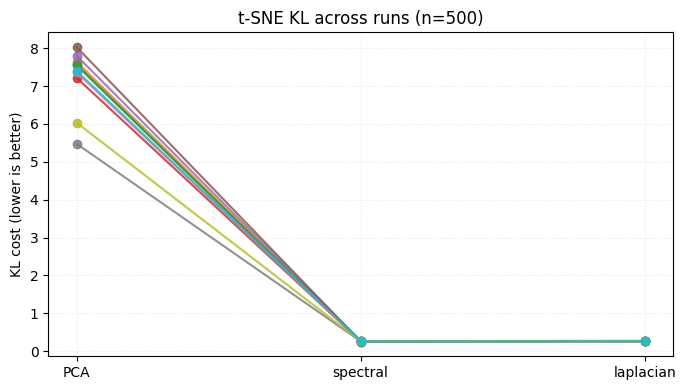

C:\Users\wpbro\AppData\Local\Temp\ipykernel_37360\1728888730.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


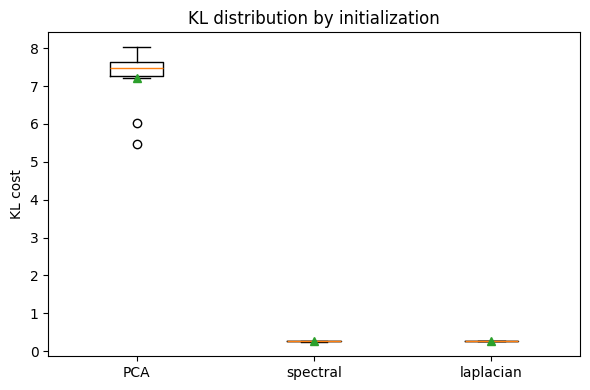

init       PCA  laplacian  spectral
run                                
0     7.576320   0.269663  0.267518
1     7.640869   0.261380  0.259793
2     7.545708   0.266791  0.254459
3     7.216442   0.266987  0.263187
4     7.802969   0.272421  0.264719
5     8.028426   0.256921  0.254409
6     7.360665   0.259808  0.256555
7     5.475936   0.266500  0.260671
8     6.031902   0.262134  0.260023
9     7.402930   0.262083  0.259015


In [ ]:
# ---------- subsample helper (stratified if y given) ----------
def subsample_indices(n_total, n=500, seed=0, y=None):
    rng = np.random.default_rng(seed)
    if y is None:
        n_take = min(n, n_total)
        return rng.choice(n_total, size=n_take, replace=False)

    # stratify roughly evenly across unique labels
    y = np.asarray(y)
    classes = np.unique(y)
    per = max(1, n // len(classes))
    idx_list = []
    for c in classes:
        pool = np.where(y == c)[0]
        take = min(per, len(pool))
        if take > 0:
            idx_list.append(rng.choice(pool, size=take, replace=False))
    idx = np.concatenate(idx_list) if idx_list else rng.choice(n_total, size=min(n, n_total), replace=False)
    return idx

# ---------- one-run evaluator on a fixed subsample ----------
def evaluate_inits_on_subsample(X, idx, inits=("PCA","spectral","laplacian"),
                                perplexity=30, T=1000, n_dimensions=2, **init_kwargs):
    Xs = X[idx]
    # Build P once using your own helpers (same as inside tsne_eigen)
    P_ij = get_original_pairwise_affinities(Xs, perplexity)
    P = get_symmetric_p_ij(P_ij)

    rows = []
    for init in inits:
        Y = tsne_eigen(
            Xs,
            perplexity=perplexity,
            T=T,
            initialization_method=init,
            n_dimensions=n_dimensions,
            **init_kwargs  # e.g., k=15, sigma=...
        )
        Q = get_low_dimensional_affinities(Y)
        KL = float(np.sum(P * np.log(P / Q)))
        rows.append({"init": init, "KL": KL})
    return pd.DataFrame(rows)

# ---------- multi-run (different subsamples), then plot ----------
def compare_inits_over_runs(X, y=None, n_runs=12, sample_size=500,
                            inits=("PCA","spectral","laplacian"),
                            perplexity=30, T=1000, n_dimensions=2, **init_kwargs):
    records = []
    for run in range(n_runs):
        idx = subsample_indices(len(X), n=sample_size, seed=run, y=y)
        df_run = evaluate_inits_on_subsample(
            X, idx,
            inits=inits,
            perplexity=perplexity,
            T=T,
            n_dimensions=n_dimensions,
            **init_kwargs
        )
        df_run["run"] = run
        records.append(df_run)
    res = pd.concat(records, ignore_index=True)

    # ---- lines plot (one polyline per run across inits) ----
    order = list(inits)
    runs = sorted(res["run"].unique())
    plt.figure(figsize=(7,4))
    for r in runs:
        row = res[res["run"]==r].set_index("init").reindex(order)
        plt.plot(range(len(order)), row["KL"].values, marker='o', alpha=0.85)
    plt.xticks(range(len(order)), order)
    plt.ylabel("KL cost (lower is better)")
    plt.title(f"t-SNE KL across runs (n={sample_size})")
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout(); plt.show()

    # ---- optional boxplot summary ----
    plt.figure(figsize=(6,4))
    data = [res[res["init"]==k]["KL"].values for k in order]
    plt.boxplot(data, labels=order, showmeans=True)
    plt.ylabel("KL cost")
    plt.title("KL distribution by initialization")
    plt.tight_layout(); plt.show()

    return res

# ==========================================================
# Load Data
# ==========================================================
DATA_PATH = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\Data\creditcard.csv"
df = pd.read_csv(DATA_PATH)

y = df["Class"].values                # Labels for stratified subsampling
X = df.drop(columns=["Class"]).values # Feature matrix for t-SNE

# ==========================================================
# Run comparison across 3 initializations on subsamples
# ==========================================================
res = compare_inits_over_runs(
    X,
    y=y,                      # Use stratified subsampling by fraud class
    n_runs=10,                 # e.g. 5 subsamples
    sample_size=500,          # each with 500 points
    inits=("PCA","spectral","laplacian"),
    perplexity=30,
    T=500,                    # iterations (increase for full optimization)
    n_dimensions=2,
    k=10                      # passed to spectral/laplacian init
)

# ==========================================================
# Inspect results
# ==========================================================
print(res.pivot_table(index="run", columns="init", values="KL"))


# Faces and coil

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.7135335083965852
Iteration 50: Value of Cost Function is 0.9107153709501101
Iteration 100: Value of Cost Function is 0.6728828402572953
Iteration 150: Value of Cost Function is 0.5740943038472713
Iteration 200: Value of Cost Function is 0.5174211595960534
Iteration 250: Value of Cost Function is 0.47943987635488106
Iteration 300: Value of Cost Function is 0.4519553614497553
Iteration 350: Value of Cost Function is 0.43091108631909436
Iteration 400: Value of Cost Function is 0.4142204970572466
Iteration 450: Value of Cost Function is 0.4004688317978876
Iteration 500: Value of Cost Function is 0.3890252039785791
Iteration 

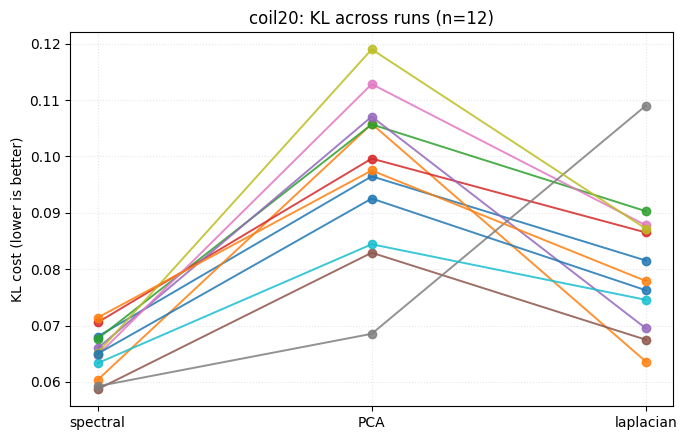

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


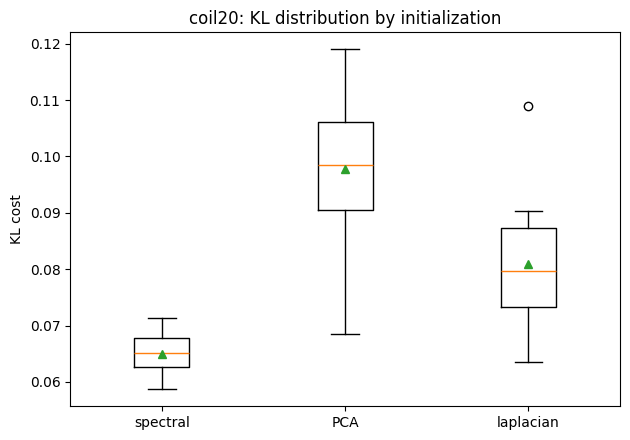

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


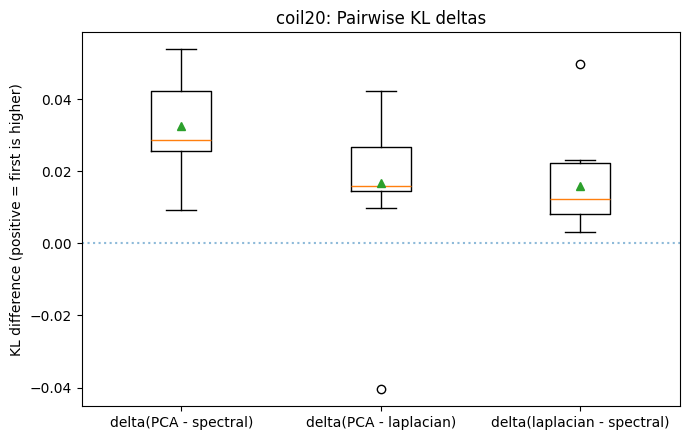

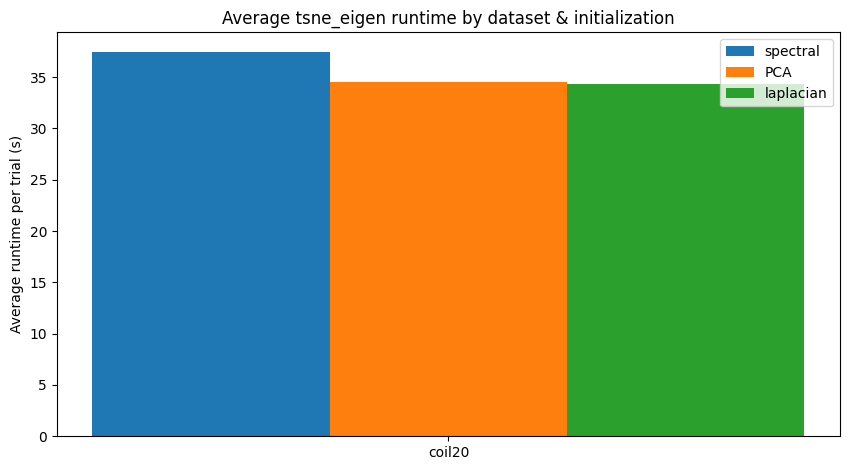

In [38]:
res_coil = run_many_tsne_comparisons_one_dataset(
    dataset_name="coil20",
    X=X_pca_coil,
    y=y_c,
    n_runs=12,
    sample_size=500,
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={},
    preprocessed_low_dim=True
)

print(res_coil.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_coil, "coil20")
plot_boxplots(res_coil, "coil20")
plot_delta_boxplots(res_coil, "coil20")
plot_time_bar_means(res_coil)

res_coil.to_csv("tsne_coil20_results.csv", index=False)

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt

fig_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(fig_dir, exist_ok=True)

def save_paired_lines(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")

    fig, ax = plt.subplots(figsize=(7,4.5))
    for r in pivot.index:
        ax.plot([0,1,2], pivot.loc[r, ["spectral","PCA","laplacian"]], marker="o", alpha=0.85)

    ax.set_xticks([0,1,2], ["spectral","PCA","laplacian"])
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL across runs")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_boxplots(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    data = [pivot[k].dropna().values for k in ["spectral","PCA","laplacian"]]

    fig, ax = plt.subplots(figsize=(6.4,4.5))
    ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_delta_boxplots(res, dataset_name, savepath):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"] == k]["KL"].values for k in keep]

    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.boxplot(data, labels=keep, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference")
    ax.set_title(f"{dataset_name}: Pairwise KL differences")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_runtime_bar(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].dropna(subset=["time_s"])
    means = sub.groupby("init")["time_s"].mean()

    fig, ax = plt.subplots(figsize=(5.5,4.2))
    ax.bar(means.index, means.values)
    ax.set_ylabel("Average runtime (s)")
    ax.set_title(f"{dataset_name}: Runtime by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

# --------- SAVE COIL-20 FIGURES ----------
save_paired_lines(res_coil, "coil20", os.path.join(fig_dir, "coil20_paired_lines.png"))
save_boxplots(res_coil, "coil20", os.path.join(fig_dir, "coil20_boxplot.png"))
save_delta_boxplots(res_coil, "coil20", os.path.join(fig_dir, "coil20_delta_boxplot.png"))
save_runtime_bar(res_coil, "coil20", os.path.join(fig_dir, "coil20_runtime_bar.png"))

print("Saved:", [f for f in os.listdir(fig_dir) if "coil20" in f])


C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\3037294067.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\3037294067.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=keep, showmeans=True)


Saved: ['coil20_boxplot.png', 'coil20_delta_boxplot.png', 'coil20_paired_lines.png', 'coil20_runtime_bar.png']


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.0623054877465519
Iteration 50: Value of Cost Function is 0.2952272344597821
Iteration 100: Value of Cost Function is 0.27324873624665214
Iteration 150: Value of Cost Function is 0.26907567101256
Iteration 200: Value of Cost Function is 0.26766909889156204
Iteration 250: Value of Cost Function is 0.2670707807520376
Iteration 300: Value of Cost Function is 0.26678849112369973
Iteration 350: Value of Cost Function is 0.2666461249013889
Iteration 400: Value of Cost Function is 0.26657093079676286
Iteration 450: Value of Cost Function is 0.26652985674461327
Iteration 500: Value of Cost Function is 0.26650681682503874
Iteratio

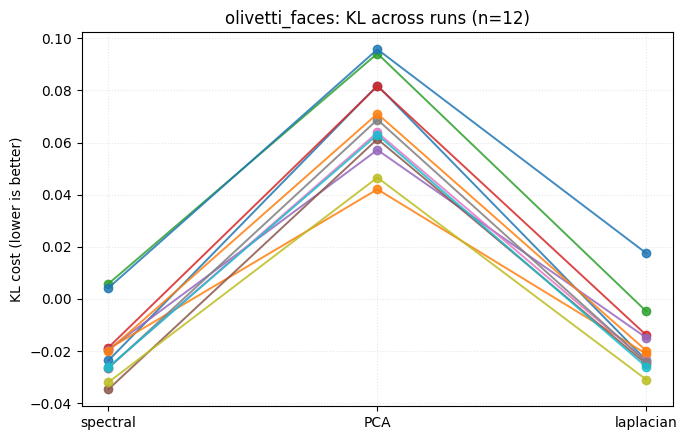

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


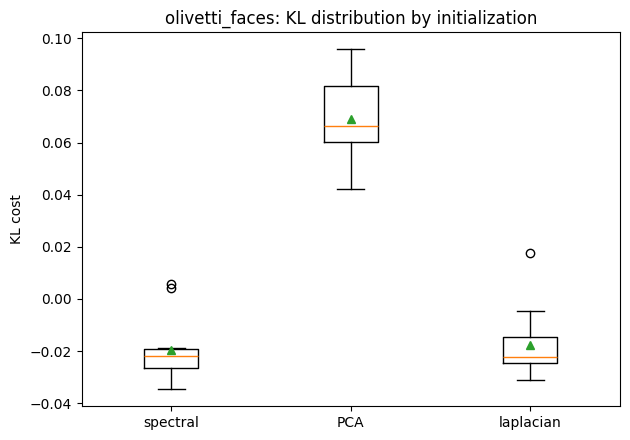

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


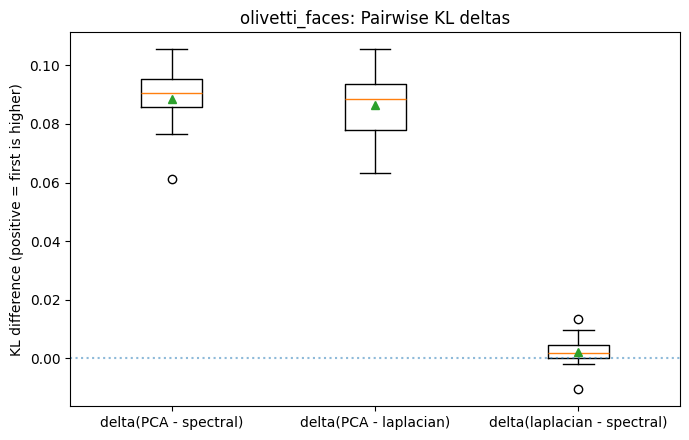

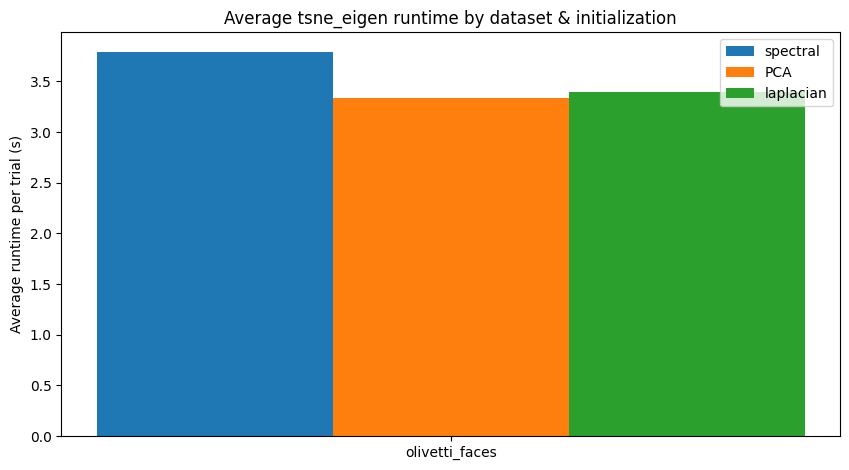

In [41]:
# Faces
res_faces = run_many_tsne_comparisons_one_dataset(
    dataset_name="olivetti_faces",
    X=X_pca_face,
    y=y_f,
    n_runs=12,
    sample_size=100,
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={},
    preprocessed_low_dim=True
)

print(res_faces.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_faces, "olivetti_faces")
plot_boxplots(res_faces, "olivetti_faces")
plot_delta_boxplots(res_faces, "olivetti_faces")
plot_time_bar_means(res_faces)

res_faces.to_csv("tsne_olivetti_faces_results.csv", index=False)

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def save_paired_lines(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")

    fig, ax = plt.subplots(figsize=(7,4.5))
    for r in pivot.index:
        ax.plot([0,1,2], pivot.loc[r, ["spectral","PCA","laplacian"]], marker="o", alpha=0.85)

    ax.set_xticks([0,1,2], ["spectral","PCA","laplacian"])
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL across runs")
    ax.grid(alpha=0.3, linestyle=":")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_boxplots(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].copy()
    pivot = sub.pivot_table(index="run", columns="init", values="KL")
    data = [pivot[k].dropna().values for k in ["spectral","PCA","laplacian"]]

    fig, ax = plt.subplots(figsize=(6.4,4.5))
    ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
    ax.set_ylabel("KL cost")
    ax.set_title(f"{dataset_name}: KL distribution by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_delta_boxplots(res, dataset_name, savepath):
    keep = ["delta(PCA - spectral)", "delta(PCA - laplacian)", "delta(laplacian - spectral)"]
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(keep))].copy()
    data = [sub[sub["init"] == k]["KL"].values for k in keep]

    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.boxplot(data, labels=keep, showmeans=True)
    ax.axhline(0.0, linestyle=":", alpha=0.5)
    ax.set_ylabel("KL difference")
    ax.set_title(f"{dataset_name}: Pairwise KL differences")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

def save_runtime_bar(res, dataset_name, savepath):
    sub = res[(res["dataset"] == dataset_name) & (res["init"].isin(["spectral","PCA","laplacian"]))].dropna(subset=["time_s"])
    means = sub.groupby("init")["time_s"].mean()

    fig, ax = plt.subplots(figsize=(5.5,4.2))
    ax.bar(means.index, means.values)
    ax.set_ylabel("Average runtime (s)")
    ax.set_title(f"{dataset_name}: Runtime by initialization")
    fig.tight_layout()
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.close(fig)


# ---- SAVE THE OLIVETTI FIGURES ----
save_paired_lines(res_faces, "olivetti_faces", os.path.join(fig_dir, "olivetti_faces_paired_lines.png"))
save_boxplots(res_faces, "olivetti_faces", os.path.join(fig_dir, "olivetti_faces_boxplot.png"))
save_delta_boxplots(res_faces, "olivetti_faces", os.path.join(fig_dir, "olivetti_faces_delta_boxplot.png"))
save_runtime_bar(res_faces, "olivetti_faces", os.path.join(fig_dir, "olivetti_faces_runtime_bar.png"))

print("Saved:", [f for f in os.listdir(fig_dir) if "olivetti" in f])


C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\226006045.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["spectral","PCA","laplacian"], showmeans=True)
C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\226006045.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=keep, showmeans=True)


Saved: ['olivetti_faces_boxplot.png', 'olivetti_faces_delta_boxplot.png', 'olivetti_faces_paired_lines.png', 'olivetti_faces_runtime_bar.png']


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 0.9587065903194982
Iteration 50: Value of Cost Function is 0.2901998240356971
Iteration 100: Value of Cost Function is 0.2800888078436681
Iteration 150: Value of Cost Function is 0.27818325687963186
Iteration 200: Value of Cost Function is 0.2776525702333232
Iteration 250: Value of Cost Function is 0.2774764324336988
Iteration 300: Value of Cost Function is 0.27740707685736593
Iteration 350: Value of Cost Function is 0.27737833385447686
Iteration 400: Value of Cost Function is 0.27736615035193124
Iteration 450: Value of Cost Function is 0.2773608734485352
Iteration 500: Value of Cost Function is 0.2773585541900941
Iteratio

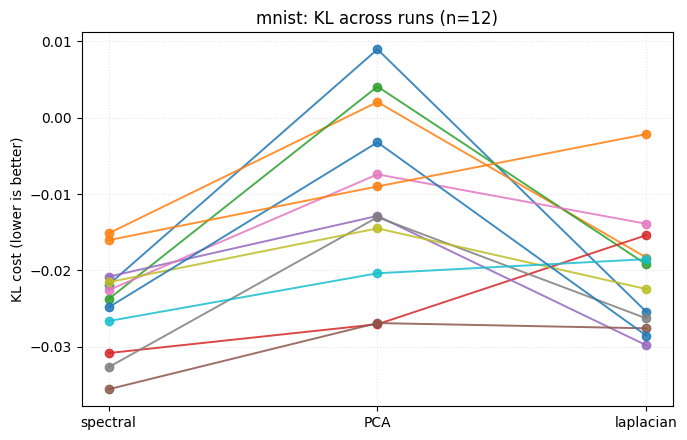

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([kl_spec, kl_pca, kl_lap], labels=["spectral","PCA","laplacian"], showmeans=True)


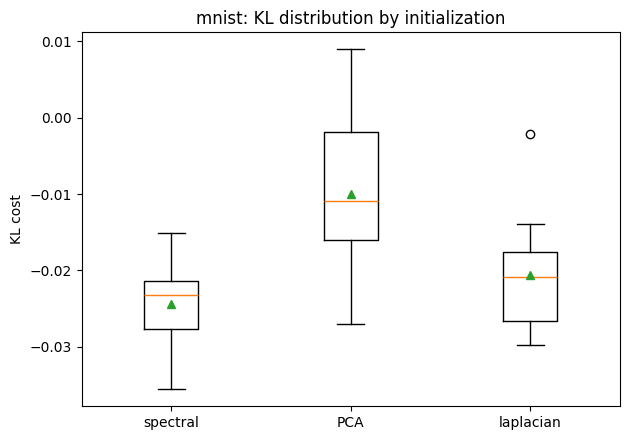

C:\Users\wpbro\AppData\Local\Temp\ipykernel_52144\1567467553.py:247: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=keep, showmeans=True)


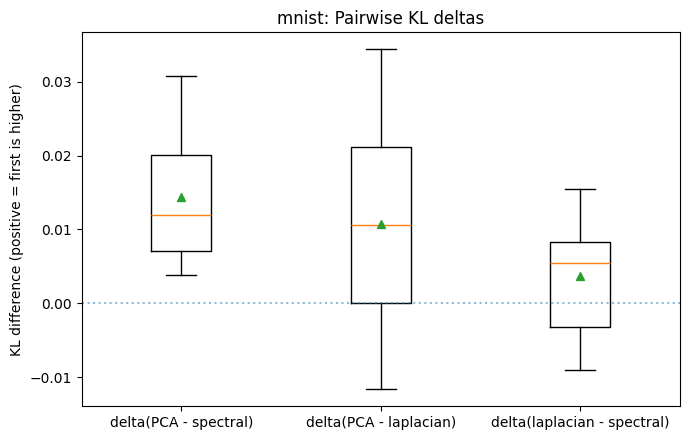

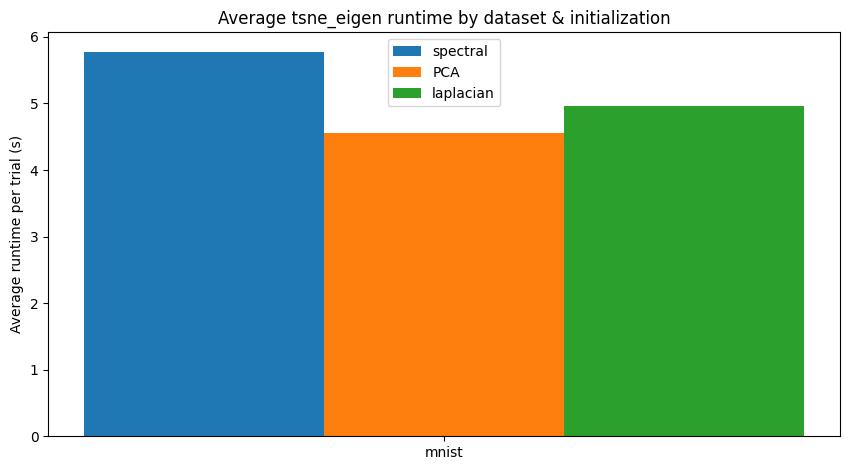

In [46]:
res_mnist = run_many_tsne_comparisons_one_dataset(
    dataset_name="mnist",
    X=x_train_pca,
    y=y_train,
    n_runs=12,
    sample_size=100,          # uses all 500 each run; set <500 to vary subsets
    perplexity=30.0,
    T=1000,
    tsne_extra_kwargs={},
    preprocessed_low_dim=True
)

print(res_mnist.pivot_table(index="run", columns="init", values="KL"))

plot_paired_lines(res_mnist, "mnist")
plot_boxplots(res_mnist, "mnist")
plot_delta_boxplots(res_mnist, "mnist")
plot_time_bar_means(res_mnist)

res_mnist.to_csv("tsne_mnist_results.csv", index=False)


In [47]:
import os
import pandas as pd

out_dir = r"C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures"
os.makedirs(out_dir, exist_ok=True)

def save_results_bundle(results_dict, out_dir, master_name="tsne_all_datasets_master.csv"):
    """
    results_dict: {"pbmc3k": res_pbmc, "creditcard": res_credit, ...}
    Saves each dataframe to its own CSV and also saves a master combined CSV.
    """
    dfs = []

    for name, df in results_dict.items():
        if df is None:
            continue
        df = df.copy()

        # Ensure dataset column is correct/consistent
        df["dataset"] = name

        # Optional: enforce consistent column order if present
        cols = [c for c in ["dataset","run","init","KL","time_s"] if c in df.columns]
        df = df[cols + [c for c in df.columns if c not in cols]]

        # Save individual CSV
        df.to_csv(os.path.join(out_dir, f"tsne_{name}_results.csv"), index=False)

        dfs.append(df)

    master = pd.concat(dfs, ignore_index=True)
    master.to_csv(os.path.join(out_dir, master_name), index=False)

    return master

# ---- Put your result dataframes here ----
results = {
    "pbmc3k": res_pbmc,
    "creditcard": res_credit,
    "images_resnet18": res_images,
    "coil20": res_coil,
    "olivetti_faces": res_faces,
    "mnist": res_mnist,          # <- include if you have it (otherwise remove this line)
}

master_df = save_results_bundle(results, out_dir)
print("Saved master to:", os.path.join(out_dir, "tsne_all_datasets_master.csv"))
print("Master shape:", master_df.shape)


Saved master to: C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\results_figures\tsne_all_datasets_master.csv
Master shape: (432, 5)


In [48]:
# Only the real inits (exclude delta rows)
inits = ["spectral", "PCA", "laplacian"]
base = master_df[master_df["init"].isin(inits)].copy()

summary = (
    base.groupby(["dataset","init"])
        .agg(
            KL_mean=("KL","mean"),
            KL_median=("KL","median"),
            KL_std=("KL","std"),
            time_mean=("time_s","mean"),
            time_median=("time_s","median"),
        )
        .reset_index()
)

summary.to_csv(os.path.join(out_dir, "tsne_summary_by_dataset_init.csv"), index=False)
summary


,dataset,init,KL_mean,KL_median,KL_std,time_mean,time_median
0,coil20,PCA,0.097690,0.098558,0.014067,34.530136,33.858119
1,coil20,laplacian,0.080961,0.079711,0.012347,34.309898,34.266285
2,coil20,spectral,0.064993,0.065064,0.004116,37.487479,37.283351
3,creditcard,PCA,0.215727,0.211009,0.023801,38.925242,33.124794
4,creditcard,laplacian,0.197488,0.195483,0.022630,36.908723,33.046695
5,creditcard,spectral,0.188512,0.187527,0.021823,39.679603,35.671886
6,images_resnet18,PCA,0.028690,0.030345,0.011304,42.637901,32.840198
7,images_resnet18,laplacian,0.030391,0.029839,0.009575,38.989299,32.736951
8,images_resnet18,spectral,0.029276,0.030725,0.010777,39.945878,35.450168
9,mnist,PCA,-0.009945,-0.010936,0.011587,4.552472,4.693656


In [49]:
delta = master_df[master_df["init"] == "delta(PCA - spectral)"].copy()

delta_summary = (
    delta.groupby("dataset")
         .agg(
             delta_mean=("KL","mean"),
             delta_median=("KL","median"),
             delta_std=("KL","std"),
             n=("KL","count")
         )
         .reset_index()
)

delta_summary.to_csv(os.path.join(out_dir, "tsne_delta_PCA_minus_spectral_summary.csv"), index=False)
delta_summary


,dataset,delta_mean,delta_median,delta_std,n
0,coil20,0.032697,0.028755,0.012798,12
1,creditcard,0.027215,0.022617,0.012279,12
2,images_resnet18,-0.000587,0.000074,0.002694,12
3,mnist,0.014419,0.011916,0.009045,12
4,olivetti_faces,0.088639,0.090566,0.011807,12
5,pbmc3k,-0.005767,-0.004672,0.006357,12
